Собираем все модели

## Импорт библиотек

In [239]:
!pip install catboost


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [240]:
import warnings
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from datetime import datetime

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [241]:
warnings.filterwarnings('ignore')

In [242]:
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

## Загрузка библиотек

In [243]:
df = pd.read_csv('climat_official.csv', parse_dates=['date'])
df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
0,34059,1981-01-01,0.1,0.4,55.25,10.00,10.000,8.00,8.000,0.00,...,0,0,0,0,0,0,0,0,0,0
1,34152,1981-01-01,-0.1,0.4,71.00,10.00,7.500,8.00,7.000,0.00,...,0,0,0,0,0,0,0,0,0,0
2,34163,1981-01-01,-1.0,0.4,80.00,10.00,7.500,8.00,6.250,0.00,...,0,0,0,0,0,0,0,0,0,0
3,34172,1981-01-01,0.4,0.0,70.00,10.00,8.750,8.00,7.250,0.00,...,0,0,0,0,0,0,0,0,0,0
4,34186,1981-01-01,-3.6,1.0,24.50,9.75,8.625,6.25,6.375,2.25,...,0,0,0,0,0,0,0,0,0,0


In [244]:
df['date'].max()

Timestamp('2024-10-26 00:00:00')

In [245]:
cutoff = pd.Timestamp('2024-09-25 00:00:00')
df = df[df['date'] <= cutoff]

In [246]:
df['date'].max()

Timestamp('2024-09-25 00:00:00')

## Предобработка

In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111818 entries, 0 to 111817
Data columns (total 51 columns):
 #   Column                                           Non-Null Count   Dtype         
---  ------                                           --------------   -----         
 0   Индекс ВМО                                       111818 non-null  int64         
 1   date                                             111818 non-null  datetime64[ns]
 2   Средняя температура воздуха                      111818 non-null  float64       
 3   Количество осадков                               111818 non-null  float64       
 4   Горизонтальная дальность видимости               111818 non-null  float64       
 5   Общее количество облачности                      111818 non-null  float64       
 6   Количество облачности нижнего яруса              111818 non-null  float64       
 7   Форма облаков верхнего яруса                     111818 non-null  float64       
 8   Форма облаков среднего яруса 

In [248]:
df.shape

(111818, 51)

### Обработка пропусков

In [249]:
df.isna().sum()

Индекс ВМО                                            0
date                                                  0
Средняя температура воздуха                           0
Количество осадков                                    0
Горизонтальная дальность видимости                    0
Общее количество облачности                           0
Количество облачности нижнего яруса                   0
Форма облаков верхнего яруса                          0
Форма облаков среднего яруса                          0
Форма облаков вертикального развития                  0
Слоистые и слоисто-кучевые облака                     0
Слоисто-дожд,разорванно-дождевые облака               0
Высота нижней границы облачности                   1071
Погода между сроками                                  0
Погода в срок наблюдения                              0
Направление ветра                                     0
Средняя скорость ветра                                0
Максимальная скорость ветра                     

In [250]:
df.interpolate(inplace=True)

In [251]:
df.isna().sum().sum()

np.int64(0)

### Обработка названий

In [252]:
# Очистка от спец символов
def clean_columns(df):
    df = df.copy()

    df.columns = (
        df.columns
        .str.replace('-', '_', regex=False)  # дефис → _
        .str.replace(',', '', regex=False)  # запятая → удалить
    )

    return df


df = clean_columns(df)

## Первичное разделение данных, чтобы не было утечек

In [253]:
df.date.min(), df.date.max()

(Timestamp('1981-01-01 00:00:00'), Timestamp('2024-09-25 00:00:00'))

In [254]:
HORIZON = 30

In [255]:
test_start = df['date'].max() - pd.Timedelta(days=HORIZON)
test_start

Timestamp('2024-08-26 00:00:00')

In [256]:
train_df = df[df['date'] < test_start]
test_df = df[df['date'] >= test_start]
train_df.shape, test_df.shape

((111601, 51), (217, 51))

In [257]:
217 / 7

31.0

### Сравнение средней тренировочной и тестовой

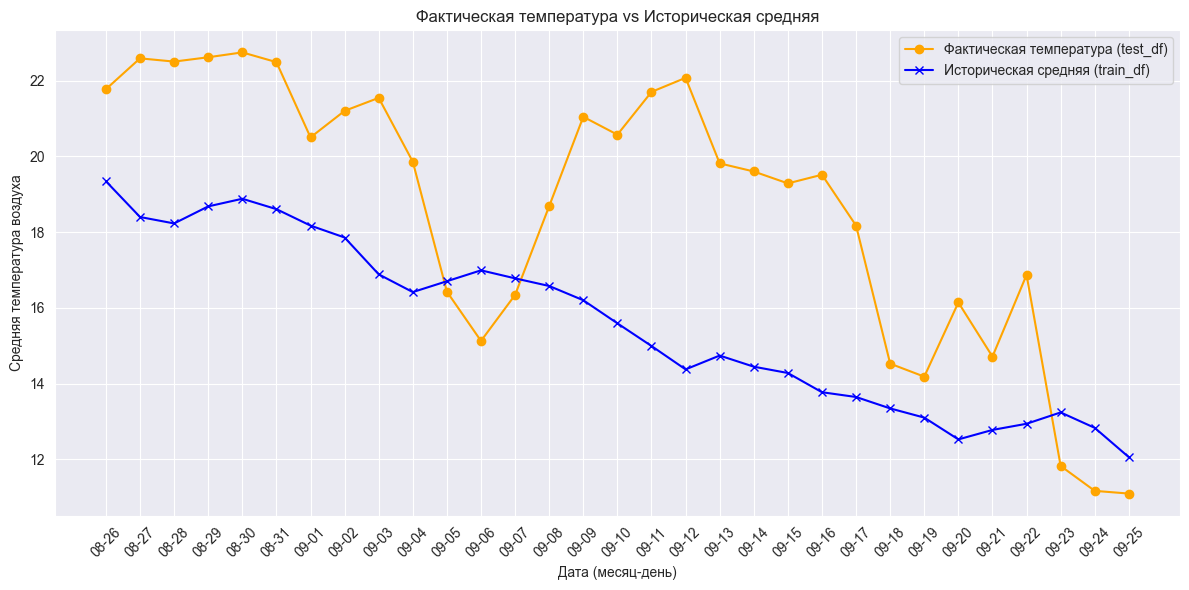

In [258]:
# Добавим колонку month_day для усреднения по дате без года
train_df['month_day'] = train_df['date'].dt.strftime('%m-%d')
test_df['month_day'] = test_df['date'].dt.strftime('%m-%d')

#  Историческая средняя по train_df для этих дней
historical_mean = train_df.groupby('month_day')['Средняя температура воздуха'].mean()

#  Фактическая средняя по дню для test_df (учитываем несколько ВМО на день)
test_daily = test_df.groupby('month_day')['Средняя температура воздуха'].mean()

plt.figure(figsize=(12, 6))

# Фактическая температура
plt.plot(test_daily.index, test_daily.values, label='Фактическая температура (test_df)', marker='o', color='orange')
# Историческая средняя
plt.plot(historical_mean.loc[test_daily.index].index, historical_mean.loc[test_daily.index].values,
         label='Историческая средняя (train_df)', marker='x', color='blue')

plt.xticks(rotation=45)
plt.xlabel('Дата (месяц-день)')
plt.ylabel('Средняя температура воздуха')
plt.title('Фактическая температура vs Историческая средняя')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Предсказывать будет не просто из-за резкого падения температуры

In [259]:
train_df = train_df.drop(columns=['month_day'])
test_df = test_df.drop(columns=['month_day'])

In [260]:
train_df.shape

(111601, 51)

### Заполнение теста Nan, чтобы не было утечек

In [261]:
test_df_nan = test_df.copy()

In [262]:
cols_to_nan = [
    c for c in test_df.columns
    if c not in ['date', 'Индекс ВМО']
       and not c.endswith('_missing')
]

test_df_nan[cols_to_nan] = np.nan

In [263]:
test_df_nan.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
111601,34059,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
111602,34152,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
111603,34163,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
111604,34172,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
111605,34186,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


### Соединение обратно

In [264]:
# Соеднияем всё в один датасет(Вал и тест - Nan)
df_merge = pd.concat([train_df, test_df_nan], ignore_index=True)
df_merge = df_merge.sort_values(['Индекс ВМО', 'date'])

In [265]:
original_cols = [col for col in df_merge.columns if col not in ['Индекс ВМО', 'date']]

In [266]:
df_merge.shape

(111818, 51)

## Общие лаги

In [267]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111818 entries, 0 to 111817
Data columns (total 51 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   Индекс ВМО                                      111818 non-null  int64         
 1   date                                            111818 non-null  datetime64[ns]
 2   Средняя температура воздуха                     111601 non-null  float64       
 3   Количество осадков                              111601 non-null  float64       
 4   Горизонтальная дальность видимости              111601 non-null  float64       
 5   Общее количество облачности                     111601 non-null  float64       
 6   Количество облачности нижнего яруса             111601 non-null  float64       
 7   Форма облаков верхнего яруса                    111601 non-null  float64       
 8   Форма облаков среднего яруса           

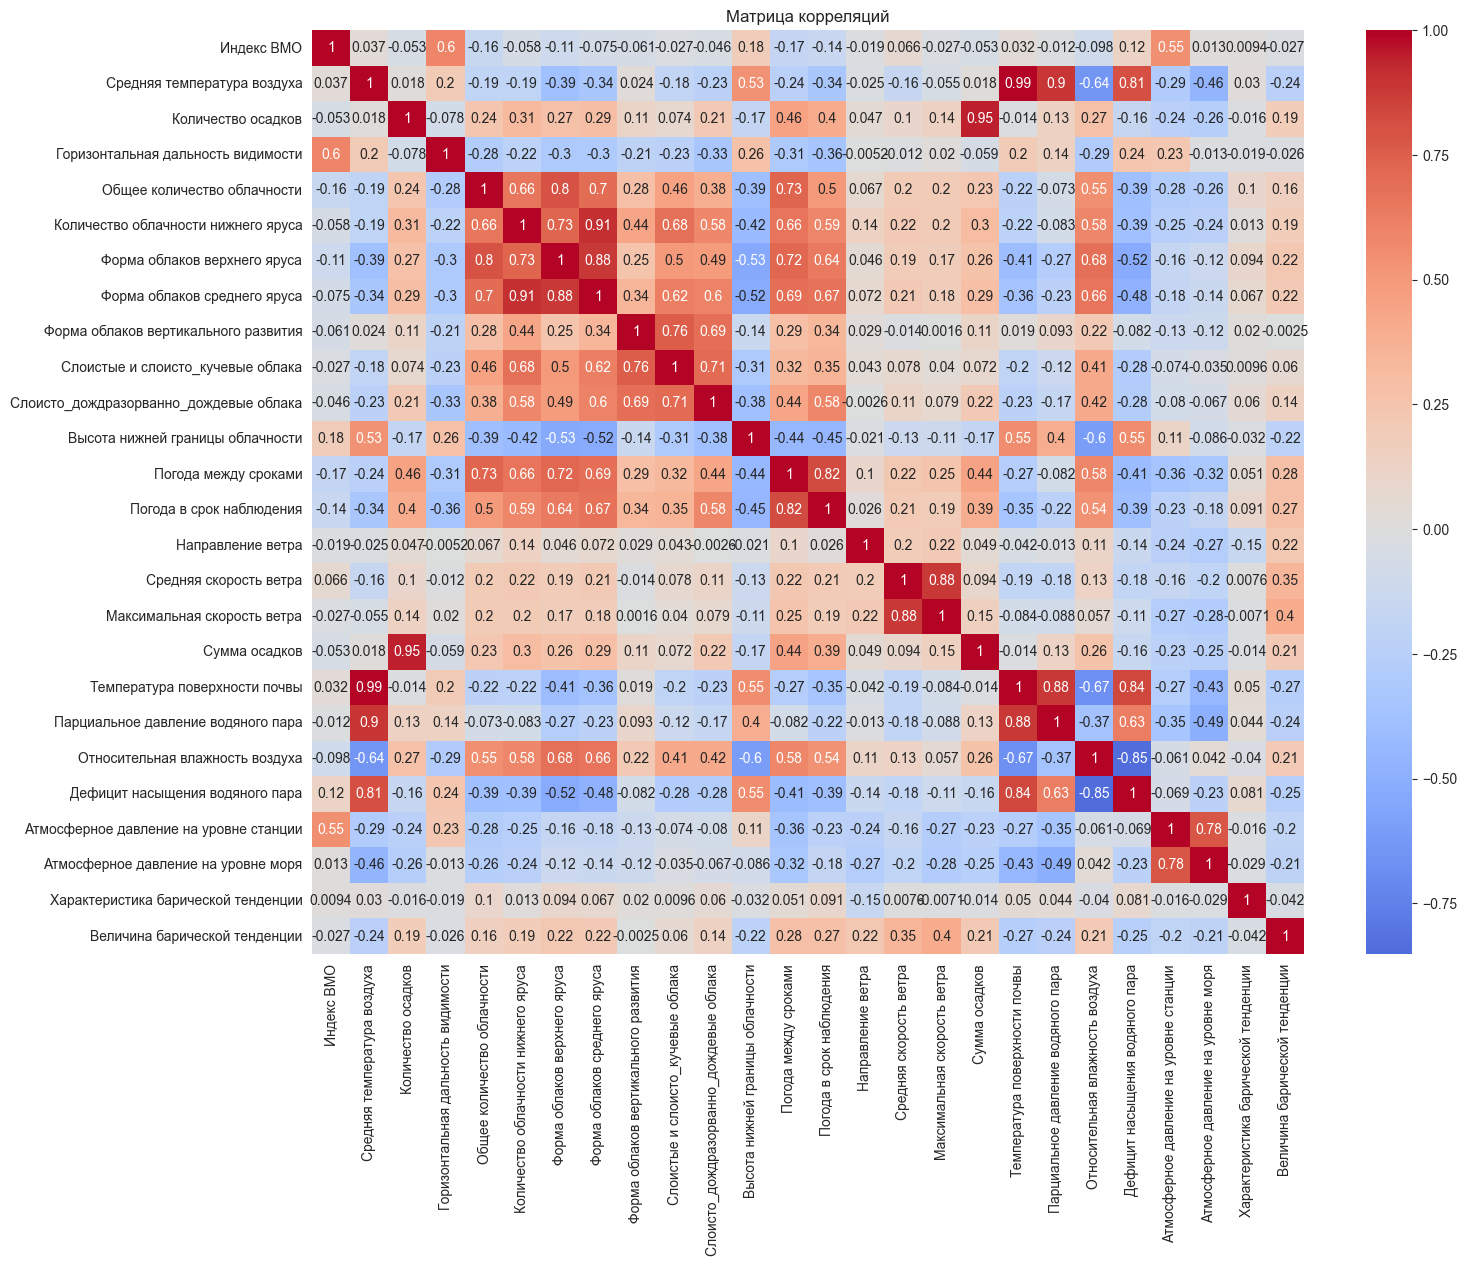

In [268]:
corr_df = df_merge.select_dtypes(include=['number'])

cols = [col for col in corr_df.columns if not col.endswith('_missing')]
corr_df = corr_df[cols]

corr_matrix = corr_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True)
plt.title('Матрица корреляций')
plt.show()

In [269]:
target_corr = corr_matrix['Средняя температура воздуха'].sort_values(ascending=False)
print(target_corr)

Средняя температура воздуха               1.000000
Температура поверхности почвы             0.986253
Парциальное давление водяного пара        0.895859
Дефицит насыщения водяного пара           0.808318
Высота нижней границы облачности          0.532021
Горизонтальная дальность видимости        0.203328
Индекс ВМО                                0.036588
Характеристика барической тенденции       0.030477
Форма облаков вертикального развития      0.024275
Количество осадков                        0.018090
Сумма осадков                             0.017701
Направление ветра                        -0.025096
Максимальная скорость ветра              -0.054944
Средняя скорость ветра                   -0.163007
Слоистые и слоисто_кучевые облака        -0.180064
Количество облачности нижнего яруса      -0.194053
Общее количество облачности              -0.194740
Слоисто_дождразорванно_дождевые облака   -0.225537
Величина барической тенденции            -0.243237
Погода между сроками           

In [270]:
key_features = [
    'Средняя температура воздуха',
    'Температура поверхности почвы',
    'Парциальное давление водяного пара',
    'Относительная влажность воздуха',
    'Дефицит насыщения водяного пара',
    'Атмосферное давление на уровне моря',
    'Атмосферное давление на уровне станции'
]

In [271]:
seasonal_lags = [335, 365, 395]

In [272]:
for col in key_features:
    for lag in seasonal_lags:
        df_merge[f'{col}_lag_{lag}'] = (
            df_merge
            .groupby('Индекс ВМО')[col]
            .shift(lag)
        )

In [273]:
df_merge.columns

Index(['Индекс ВМО', 'date', 'Средняя температура воздуха',
       'Количество осадков', 'Горизонтальная дальность видимости',
       'Общее количество облачности', 'Количество облачности нижнего яруса',
       'Форма облаков верхнего яруса', 'Форма облаков среднего яруса',
       'Форма облаков вертикального развития',
       'Слоистые и слоисто_кучевые облака',
       'Слоисто_дождразорванно_дождевые облака',
       'Высота нижней границы облачности', 'Погода между сроками',
       'Погода в срок наблюдения', 'Направление ветра',
       'Средняя скорость ветра', 'Максимальная скорость ветра',
       'Сумма осадков', 'Температура поверхности почвы',
       'Парциальное давление водяного пара', 'Относительная влажность воздуха',
       'Дефицит насыщения водяного пара',
       'Атмосферное давление на уровне станции',
       'Атмосферное давление на уровне моря',
       'Характеристика барической тенденции', 'Величина барической тенденции',
       'Горизонтальная дальность видимости_mi

In [274]:
df_merge.shape

(111818, 72)

In [275]:
df_merge.date.min(), df_merge.date.max()

(Timestamp('1981-01-01 00:00:00'), Timestamp('2024-09-25 00:00:00'))

### Избавление от пропусков после добавеления лагов

In [276]:
# Для каждой группы находим первую дату без NaN
def first_valid_date_per_group(df, group_col='Индекс ВМО', date_col='date'):
    # Словарь: индекс ВМО - дата первой строки без NaN
    first_dates = {}

    for idx, group in df.groupby(group_col):
        # Проверяем только колонки с NaN
        valid_rows = group[~group.isna().any(axis=1)]
        if not valid_rows.empty:
            first_dates[idx] = valid_rows[date_col].iloc[0]
        else:
            first_dates[idx] = None  # если все строки пустые

    return first_dates


first_dates_dict = first_valid_date_per_group(df_merge)
first_dates_dict

{34059: Timestamp('1982-01-31 00:00:00'),
 34152: Timestamp('1982-01-31 00:00:00'),
 34163: Timestamp('1982-01-31 00:00:00'),
 34172: Timestamp('1982-01-31 00:00:00'),
 34186: Timestamp('1982-01-31 00:00:00'),
 34289: Timestamp('1982-01-31 00:00:00'),
 34391: Timestamp('1982-01-31 00:00:00')}

Обрезаем на 365 дней

In [277]:
# Обрезаем каждую группу по дате
cleaned_groups = []
for idx, group in df_merge.groupby('Индекс ВМО'):
    start_date = first_dates_dict[idx]
    cleaned_group = group[group['date'] >= start_date]
    cleaned_groups.append(cleaned_group)

clean_lagged_df = pd.concat(cleaned_groups).reset_index(drop=True)

In [278]:
clean_lagged_df.shape

(109053, 72)

In [279]:
clean_lagged_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Относительная влажность воздуха_lag_395,Дефицит насыщения водяного пара_lag_335,Дефицит насыщения водяного пара_lag_365,Дефицит насыщения водяного пара_lag_395,Атмосферное давление на уровне моря_lag_335,Атмосферное давление на уровне моря_lag_365,Атмосферное давление на уровне моря_lag_395,Атмосферное давление на уровне станции_lag_335,Атмосферное давление на уровне станции_lag_365,Атмосферное давление на уровне станции_lag_395
0,34059,1982-01-31,-9.2,0.0,69.125,5.125,0.0,0.750,0.000,0.0,...,93.375,0.7375,0.1500,0.4500,1030.9875,1006.8625,1003.0375,1009.8625,986.2625,983.0500
1,34059,1982-02-01,-11.8,0.0,68.125,3.375,0.0,1.750,0.125,0.0,...,94.250,0.5250,0.4625,0.3625,1022.8500,1000.6250,1000.3125,1001.6875,980.2000,980.3750
2,34059,1982-02-02,-15.2,0.0,67.625,1.000,0.0,0.375,0.000,0.0,...,91.875,0.5375,0.5500,0.4500,1019.1125,996.4875,1004.8875,998.0875,975.9750,984.6000
3,34059,1982-02-03,-16.3,0.0,53.500,0.625,0.0,0.250,0.000,0.0,...,89.000,0.1000,0.6625,0.5625,1003.2125,1000.2750,1001.6875,982.8500,979.7625,981.3750
4,34059,1982-02-04,-17.4,0.0,55.000,5.000,0.0,2.500,0.625,0.0,...,91.250,0.4500,0.6750,0.5125,1011.6500,993.8375,999.5375,991.1250,973.9625,979.3875


## Конструирование признаков

In [280]:
clean_lagged_df.describe()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Относительная влажность воздуха_lag_395,Дефицит насыщения водяного пара_lag_335,Дефицит насыщения водяного пара_lag_365,Дефицит насыщения водяного пара_lag_395,Атмосферное давление на уровне моря_lag_335,Атмосферное давление на уровне моря_lag_365,Атмосферное давление на уровне моря_lag_395,Атмосферное давление на уровне станции_lag_335,Атмосферное давление на уровне станции_lag_365,Атмосферное давление на уровне станции_lag_395
count,109053.000000,109053,108836.000000,108836.000000,108836.00000,108836.000000,108836.000000,108836.000000,108836.000000,108836.000000,...,109053.000000,109053.000000,109053.000000,109053.000000,109053.000000,109053.000000,109053.000000,109053.000000,109053.000000,109053.000000
mean,34201.714286,2003-05-30 00:00:00,6.910289,1.168612,88.00999,6.518854,3.197201,3.088858,2.183116,0.403365,...,71.127795,5.659102,5.652675,5.636893,1017.553751,1017.567368,1017.572127,1003.138546,1003.150418,1003.152808
min,34059.000000,1982-01-31 00:00:00,-31.300000,0.000000,2.50000,0.000000,0.000000,0.000000,0.000000,0.000000,...,16.000000,0.000000,0.000000,0.000000,978.725000,978.725000,978.725000,956.325000,956.325000,956.325000
25%,34152.000000,1992-09-29 00:00:00,-2.600000,0.000000,82.25000,4.000000,0.250000,0.500000,0.250000,0.000000,...,57.875000,0.603750,0.600000,0.597500,1010.937500,1010.937500,1010.937500,994.575000,994.575000,994.575000
50%,34172.000000,2003-05-30 00:00:00,7.600000,0.000000,96.25000,7.125000,2.250000,2.125000,1.000000,0.000000,...,73.875000,2.650000,2.630000,2.597500,1016.462500,1016.475000,1016.475000,1002.312500,1002.312500,1002.325000
75%,34289.000000,2014-01-27 00:00:00,17.800000,0.600000,97.50000,9.500000,5.000000,5.375000,3.500000,0.500000,...,85.750000,9.000000,9.000000,8.973750,1023.150000,1023.175000,1023.200000,1010.900000,1010.925000,1010.937500
max,34391.000000,2024-09-25 00:00:00,34.300000,96.400000,99.00000,13.000000,13.000000,9.000000,9.000000,9.000000,...,100.000000,45.596250,45.596250,45.596250,1058.787500,1058.787500,1058.787500,1054.675000,1054.675000,1054.675000
std,99.222737,NaN,12.634050,3.340948,13.44274,3.212658,3.257144,2.810611,2.482736,0.849690,...,17.452765,6.633036,6.635435,6.635859,9.647006,9.672964,9.680440,11.944029,11.963235,11.969954


### Работа с датой

In [281]:
# Разбор даты на год, месяц, день для clean_lagged_df
clean_lagged_df['year'] = clean_lagged_df['date'].dt.year
clean_lagged_df['month'] = clean_lagged_df['date'].dt.month
clean_lagged_df['day'] = clean_lagged_df['date'].dt.day

# Проверка
clean_lagged_df[['date', 'year', 'month', 'day']].head()

,date,year,month,day
0,1982-01-31,1982,1,31
1,1982-02-01,1982,2,1
2,1982-02-02,1982,2,2
3,1982-02-03,1982,2,3
4,1982-02-04,1982,2,4


In [282]:
# День в году (Синус + косинус)
clean_lagged_df['day_of_year'] = clean_lagged_df['date'].dt.dayofyear

clean_lagged_df['day_of_year_sin'] = np.sin(2 * np.pi * clean_lagged_df['day_of_year'] / 365)
clean_lagged_df['day_of_year_cos'] = np.cos(2 * np.pi * clean_lagged_df['day_of_year'] / 365)

clean_lagged_df = clean_lagged_df.drop(columns='day_of_year')

In [283]:
# Сезон (1-зима, 2-весна, 3-лето, 4-осень)
clean_lagged_df['season'] = ((clean_lagged_df['date'].dt.month % 12 + 3) // 3).astype(int)

In [284]:
clean_lagged_df['month_sin'] = np.sin(2 * np.pi * clean_lagged_df['month'] / 12)
clean_lagged_df['month_cos'] = np.cos(2 * np.pi * clean_lagged_df['month'] / 12)

clean_lagged_df = clean_lagged_df.drop(columns=['month'])

In [285]:
clean_lagged_df.shape

(109053, 79)

### Добавление статистик

#### Среднее для температуры

In [286]:
# Создаём колонку day_of_year без учёта года
clean_lagged_df['month_day'] = clean_lagged_df['date'].dt.strftime('%m-%d')

# Группировка по Индексу ВМО и дню-месяца
temp_mean = (
    clean_lagged_df
    .groupby(['Индекс ВМО', 'month_day'])['Средняя температура воздуха']
    .mean()
    .reset_index()
    .rename(columns={'Средняя температура воздуха': 'Средняя температура воздуха_mean_group'})
)

# Объединяем обратно с основным датасетом
clean_lagged_df = clean_lagged_df.merge(temp_mean, on=['Индекс ВМО', 'month_day'], how='left')


#### Отклонение температуры этого ВМО от среднего по всем остальным ВМО в тот же день/месяц

In [287]:
# Считаем среднее по всем ВМО для каждой даты (day+month)
mean_all_stations = (
    clean_lagged_df
    .groupby('month_day')['Средняя температура воздуха_mean_group']
    .transform('mean')
)

# Создаём новый признак: отклонение от среднего по остальным станциям
clean_lagged_df['temp_delta_vs_all_stations'] = clean_lagged_df[
                                                    'Средняя температура воздуха_mean_group'] - mean_all_stations

clean_lagged_df.drop(columns=['month_day'], inplace=True)

In [288]:
clean_lagged_df.tail()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Атмосферное давление на уровне станции_lag_395,year,day,day_of_year_sin,day_of_year_cos,season,month_sin,month_cos,Средняя температура воздуха_mean_group,temp_delta_vs_all_stations
109048,34391,2024-09-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1005.9750,2024,21,-0.988678,-0.150055,4,-1.0,-1.836970e-16,14.271429,1.370408
109049,34391,2024-09-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1005.5875,2024,22,-0.991114,-0.133015,4,-1.0,-1.836970e-16,14.116667,1.074490
109050,34391,2024-09-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1006.6125,2024,23,-0.993257,-0.115935,4,-1.0,-1.836970e-16,14.230952,0.989116
109051,34391,2024-09-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1011.2750,2024,24,-0.995105,-0.098820,4,-1.0,-1.836970e-16,13.976190,1.203741
109052,34391,2024-09-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1007.9375,2024,25,-0.996659,-0.081676,4,-1.0,-1.836970e-16,13.135714,1.150340


### Удаление столбцов _missing

In [289]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    clean_lagged_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109053 entries, 0 to 109052
Data columns (total 81 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   Индекс ВМО                                      109053 non-null  int64         
 1   date                                            109053 non-null  datetime64[ns]
 2   Средняя температура воздуха                     108836 non-null  float64       
 3   Количество осадков                              108836 non-null  float64       
 4   Горизонтальная дальность видимости              108836 non-null  float64       
 5   Общее количество облачности                     108836 non-null  float64       
 6   Количество облачности нижнего яруса             108836 non-null  float64       
 7   Форма облаков верхнего яруса                    108836 non-null  float64       
 8   Форма облаков среднего яруса      

In [290]:
cols_to_drop = [col for col in clean_lagged_df.columns if col.endswith('_missing')]
clean_lagged_df = clean_lagged_df.drop(columns=cols_to_drop)

In [291]:
clean_lagged_df.shape

(109053, 57)

## Работа с выбросами

### Работа с temp_delta_vs_all_stations


In [292]:
clean_lagged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109053 entries, 0 to 109052
Data columns (total 57 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   Индекс ВМО                                      109053 non-null  int64         
 1   date                                            109053 non-null  datetime64[ns]
 2   Средняя температура воздуха                     108836 non-null  float64       
 3   Количество осадков                              108836 non-null  float64       
 4   Горизонтальная дальность видимости              108836 non-null  float64       
 5   Общее количество облачности                     108836 non-null  float64       
 6   Количество облачности нижнего яруса             108836 non-null  float64       
 7   Форма облаков верхнего яруса                    108836 non-null  float64       
 8   Форма облаков среднего яруса      

In [293]:
clean_lagged_df['temp_delta_vs_all_stations'].describe()

count    1.090530e+05
mean     6.671946e-17
std      8.928028e-01
min     -2.039867e+00
25%     -7.332226e-01
50%      3.605442e-02
75%      6.163265e-01
max      2.629900e+00
Name: temp_delta_vs_all_stations, dtype: float64

In [294]:
col = 'temp_delta_vs_all_stations'

#  глобальные границы
mean = clean_lagged_df[col].mean()
std = clean_lagged_df[col].std()

global_upper = mean + 2.5 * std
global_lower = mean - 2.5 * std

In [295]:
#  rolling
rolling_mean = clean_lagged_df[col].rolling(window=30, center=True).mean()
rolling_std = clean_lagged_df[col].rolling(window=30, center=True).std()

upper = rolling_mean + 2.5 * rolling_std
lower = rolling_mean - 2.5 * rolling_std

In [296]:
# заполняем границы (а не данные!)
upper = upper.fillna(global_upper)
lower = lower.fillna(global_lower)

In [297]:
clean_lagged_df[col] = np.minimum(
    np.maximum(clean_lagged_df[col], lower),
    upper
)

In [298]:
clean_lagged_df['temp_delta_vs_all_stations'].describe()

count    109053.000000
mean          0.000031
std           0.892443
min          -2.039867
25%          -0.733223
50%           0.036054
75%           0.616327
max           2.622453
Name: temp_delta_vs_all_stations, dtype: float64

Статистики практически не изменились

In [299]:
clean_lagged_df.shape

(109053, 57)

## Разделение на тренировочную/тестовую


In [300]:
df_for_training = clean_lagged_df.copy()

In [301]:
df_for_training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109053 entries, 0 to 109052
Data columns (total 57 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   Индекс ВМО                                      109053 non-null  int64         
 1   date                                            109053 non-null  datetime64[ns]
 2   Средняя температура воздуха                     108836 non-null  float64       
 3   Количество осадков                              108836 non-null  float64       
 4   Горизонтальная дальность видимости              108836 non-null  float64       
 5   Общее количество облачности                     108836 non-null  float64       
 6   Количество облачности нижнего яруса             108836 non-null  float64       
 7   Форма облаков верхнего яруса                    108836 non-null  float64       
 8   Форма облаков среднего яруса      

In [302]:
test_start

Timestamp('2024-08-26 00:00:00')

### Восстановление значений

In [303]:
target_col = 'Средняя температура воздуха'

In [304]:
df_for_training.isna().sum()

Индекс ВМО                                          0
date                                                0
Средняя температура воздуха                       217
Количество осадков                                217
Горизонтальная дальность видимости                217
Общее количество облачности                       217
Количество облачности нижнего яруса               217
Форма облаков верхнего яруса                      217
Форма облаков среднего яруса                      217
Форма облаков вертикального развития              217
Слоистые и слоисто_кучевые облака                 217
Слоисто_дождразорванно_дождевые облака            217
Высота нижней границы облачности                  217
Погода между сроками                              217
Погода в срок наблюдения                          217
Направление ветра                                 217
Средняя скорость ветра                            217
Максимальная скорость ветра                       217
Сумма осадков               

В начале делали тест Nan, чтобы не было утечек, теперь восстанавливаем значения


In [305]:
test_df.isna().sum().sum()

np.int64(0)

In [306]:
test_df.columns

Index(['Индекс ВМО', 'date', 'Средняя температура воздуха',
       'Количество осадков', 'Горизонтальная дальность видимости',
       'Общее количество облачности', 'Количество облачности нижнего яруса',
       'Форма облаков верхнего яруса', 'Форма облаков среднего яруса',
       'Форма облаков вертикального развития',
       'Слоистые и слоисто_кучевые облака',
       'Слоисто_дождразорванно_дождевые облака',
       'Высота нижней границы облачности', 'Погода между сроками',
       'Погода в срок наблюдения', 'Направление ветра',
       'Средняя скорость ветра', 'Максимальная скорость ветра',
       'Сумма осадков', 'Температура поверхности почвы',
       'Парциальное давление водяного пара', 'Относительная влажность воздуха',
       'Дефицит насыщения водяного пара',
       'Атмосферное давление на уровне станции',
       'Атмосферное давление на уровне моря',
       'Характеристика барической тенденции', 'Величина барической тенденции',
       'Горизонтальная дальность видимости_mi

In [307]:
keys = ['Индекс ВМО', 'date']

df_cur = df_for_training.set_index(keys)
df_old = test_df.set_index(keys)

# берём только пересечение колонок
common_cols = df_cur.columns.intersection(df_old.columns)

df_cur[common_cols] = df_cur[common_cols].combine_first(df_old[common_cols])

df_for_training = df_cur.reset_index()

In [308]:
df_for_training.isna().sum()

Индекс ВМО                                        0
date                                              0
Средняя температура воздуха                       0
Количество осадков                                0
Горизонтальная дальность видимости                0
Общее количество облачности                       0
Количество облачности нижнего яруса               0
Форма облаков верхнего яруса                      0
Форма облаков среднего яруса                      0
Форма облаков вертикального развития              0
Слоистые и слоисто_кучевые облака                 0
Слоисто_дождразорванно_дождевые облака            0
Высота нижней границы облачности                  0
Погода между сроками                              0
Погода в срок наблюдения                          0
Направление ветра                                 0
Средняя скорость ветра                            0
Максимальная скорость ветра                       0
Сумма осадков                                     0
Температура 

In [309]:
df_for_training.tail(8)

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Атмосферное давление на уровне станции_lag_395,year,day,day_of_year_sin,day_of_year_cos,season,month_sin,month_cos,Средняя температура воздуха_mean_group,temp_delta_vs_all_stations
109045,34391,2024-09-18,13.8,0.0,97.0,0.375,0.000,0.375,0.000,0.000,...,1012.3500,2024,18,-0.979614,-0.200891,4,-1.0,-1.836970e-16,14.561905,1.163946
109046,34391,2024-09-19,14.4,0.0,97.0,0.375,0.000,0.250,0.000,0.000,...,1007.5500,2024,19,-0.982927,-0.183998,4,-1.0,-1.836970e-16,14.642857,1.426531
109047,34391,2024-09-20,15.8,0.0,97.0,5.125,1.625,1.000,0.375,0.250,...,1005.4000,2024,20,-0.985948,-0.167052,4,-1.0,-1.836970e-16,13.964286,1.303401
109048,34391,2024-09-21,15.4,0.0,97.0,2.250,0.000,0.625,0.125,0.000,...,1005.9750,2024,21,-0.988678,-0.150055,4,-1.0,-1.836970e-16,14.271429,1.370408
109049,34391,2024-09-22,18.0,0.0,97.0,0.625,0.375,0.125,0.000,0.125,...,1005.5875,2024,22,-0.991114,-0.133015,4,-1.0,-1.836970e-16,14.116667,1.074490
109050,34391,2024-09-23,13.7,0.0,97.0,0.750,0.000,0.625,0.000,0.000,...,1006.6125,2024,23,-0.993257,-0.115935,4,-1.0,-1.836970e-16,14.230952,0.989116
109051,34391,2024-09-24,10.9,0.0,97.0,4.875,0.000,1.125,0.000,0.000,...,1011.2750,2024,24,-0.995105,-0.098820,4,-1.0,-1.836970e-16,13.976190,1.203741
109052,34391,2024-09-25,11.6,0.0,97.0,0.250,0.000,0.250,0.000,0.000,...,1007.9375,2024,25,-0.996659,-0.081676,4,-1.0,-1.836970e-16,13.135714,1.150340


![image.png](attachment:04764ccb-4c1c-4fb2-b8a7-35aadf2d22fa.png)

Скриншот из изначальных данных для проверки

## Сохранение датасетов для отдельных моделей

In [310]:
df_for_one = df_for_training.copy()
df_for_two = df_for_training.copy()
df_for_three = df_for_training.copy()
df_for_four = df_for_training.copy()
df_for_five = df_for_training.copy()
df_for_lstm = df_for_training.copy()

In [311]:
# df_for_training.to_csv('df_for_lstm_main.csv')

LSTM будем делать отдельно, а потом загрузим предсказания

## LSTM

### Метрики оценки точности

#### Простые метрики

In [312]:
def simple_metric(y_val, y_pred):
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_val - y_pred) / y_val)) * 100
    r2 = r2_score(y_val, y_pred)

    print("Простые метрики:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²: {r2:.4f}")
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

#### Ошибки по дням

In [313]:
def daily_metrics_lstm(val_df, y_pred, station_ids,
                       date_col='date',
                       station_col='Индекс ВМО',
                       target_col='Средняя температура воздуха'):
    val_df = val_df.sort_values([station_col, date_col]).copy()
    horizon = y_pred.shape[1]

    rows = []

    for i, station_id in enumerate(station_ids):
        station_df = val_df[val_df[station_col] == station_id].copy()
        station_df = station_df.sort_values(date_col)

        if len(station_df) < horizon:
            continue

        station_df = station_df.tail(horizon)
        station_df['prediction'] = y_pred[i]

        rows.append(station_df)

    df_plot = pd.concat(rows, axis=0)

    results = []

    for date, group in df_plot.groupby(date_col):
        y_true = group[target_col].values
        y_hat = group['prediction'].values

        mae = mean_absolute_error(y_true, y_hat)
        rmse = np.sqrt(mean_squared_error(y_true, y_hat))
        r2 = r2_score(y_true, y_hat)

        results.append({
            'date': date,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    return pd.DataFrame(results).sort_values('date')

#### Столбчатые диаграммы ошибок по индексам


In [314]:
def metrics_per_index_lstm(val_df, y_pred, station_ids,
                           index_col='Индекс ВМО',
                           date_col='date',
                           target_col='Средняя температура воздуха'):
    val_df = val_df.sort_values([index_col, date_col]).copy()
    horizon = y_pred.shape[1]

    rows = []
    for i, station_id in enumerate(station_ids):
        station_df = val_df[val_df[index_col] == station_id].copy()
        station_df = station_df.sort_values(date_col)

        if len(station_df) < horizon:
            continue

        station_df = station_df.tail(horizon)
        station_df['prediction'] = y_pred[i]

        rows.append(station_df)

    df_plot = pd.concat(rows, axis=0)

    metrics_list = []

    for idx, group in df_plot.groupby(index_col):
        y_true = group[target_col].values
        y_hat = group['prediction'].values

        mae = mean_absolute_error(y_true, y_hat)
        rmse = np.sqrt(mean_squared_error(y_true, y_hat))
        r2 = r2_score(y_true, y_hat) if len(y_true) > 1 else np.nan

        metrics_list.append({
            index_col: idx,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    metrics_df = pd.DataFrame(metrics_list).sort_values(index_col)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    axes[0].bar(metrics_df[index_col].astype(str), metrics_df['MAE'])
    axes[0].set_title('MAE по индексам')
    axes[0].set_ylabel('MAE')

    axes[1].bar(metrics_df[index_col].astype(str), metrics_df['RMSE'])
    axes[1].set_title('RMSE по индексам')
    axes[1].set_ylabel('RMSE')

    axes[2].bar(metrics_df[index_col].astype(str), metrics_df['R2'])
    axes[2].set_title('R² по индексам')
    axes[2].set_ylabel('R²')

    for ax in axes:
        ax.set_xlabel('Индекс ВМО')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return metrics_df

#### Линейный график MAE

In [315]:
def cumulative_mae_lstm(val_df, y_pred, station_ids,
                        date_col='date',
                        station_col='Индекс ВМО',
                        target_col='Средняя температура воздуха'):
    val_df = val_df.sort_values([station_col, date_col]).copy()
    horizon = y_pred.shape[1]

    rows = []

    for i, station_id in enumerate(station_ids):
        station_df = val_df[val_df[station_col] == station_id].copy()
        station_df = station_df.sort_values(date_col)

        if len(station_df) < horizon:
            continue

        station_df = station_df.tail(horizon)
        station_df['prediction'] = y_pred[i]

        rows.append(station_df)

    df_plot = pd.concat(rows, axis=0)

    df_plot = df_plot.sort_values(date_col)

    cum_errors = []
    all_true = []
    all_pred = []

    for date, group in df_plot.groupby(date_col):
        all_true.extend(group[target_col].values)
        all_pred.extend(group['prediction'].values)

        mae = mean_absolute_error(all_true, all_pred)

        cum_errors.append({
            'date': date,
            'Cumulative_MAE': mae
        })

    cum_df = pd.DataFrame(cum_errors)

    plt.figure(figsize=(12, 5))
    plt.plot(cum_df['date'], cum_df['Cumulative_MAE'], marker='o')
    plt.xlabel('Дата')
    plt.ylabel('MAE')
    plt.title('MAE по дням (LSTM)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return cum_df

#### Накопление ошибки Mae


In [316]:
def cumulative_error_lstm(val_df, y_pred, station_ids,
                          date_col='date',
                          station_col='Индекс ВМО',
                          target_col='Средняя температура воздуха'):
    val_df = val_df.sort_values([station_col, date_col]).copy()
    horizon = y_pred.shape[1]

    rows = []

    for i, station_id in enumerate(station_ids):
        station_df = val_df[val_df[station_col] == station_id].copy()
        station_df = station_df.sort_values(date_col)

        if len(station_df) < horizon:
            continue

        station_df = station_df.tail(horizon)
        station_df['prediction'] = y_pred[i]

        rows.append(station_df)

    df_plot = pd.concat(rows, axis=0)

    df_plot = df_plot.sort_values(date_col)

    cum_errors = []
    total_error = 0

    for date, group in df_plot.groupby(date_col):
        daily_error = np.abs(group[target_col] - group['prediction']).sum()
        total_error += daily_error

        cum_errors.append({
            'date': date,
            'Cumulative_Error': total_error
        })

    cum_df = pd.DataFrame(cum_errors)

    plt.figure(figsize=(12, 5))
    plt.plot(cum_df['date'], cum_df['Cumulative_Error'], marker='o')
    plt.xlabel('Дата')
    plt.ylabel('Cumulative Absolute Error')
    plt.title('Накопление абсолютной ошибки (LSTM)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return cum_df

#### Сравнения истинной средней и предсказанной средней


In [317]:
def plot_true_vs_pred(val_df, y_pred, station_ids,
                      date_col='date',
                      station_col='Индекс ВМО',
                      target_col='Средняя температура воздуха'):
    val_df = val_df.sort_values([station_col, date_col]).copy()

    preds_list = []

    horizon = y_pred.shape[1]

    for i, station_id in enumerate(station_ids):
        station_df = val_df[val_df[station_col] == station_id].copy()
        station_df = station_df.sort_values(date_col)

        if len(station_df) < horizon:
            continue

        # берём последние 30 дней
        station_df = station_df.tail(horizon)

        station_df['prediction'] = y_pred[i]
        preds_list.append(station_df)

    if len(preds_list) == 0:
        raise ValueError("Нет данных для построения графика")

    df_plot = pd.concat(preds_list, axis=0)

    # агрегируем по дате
    daily_true = df_plot.groupby(date_col)[target_col].mean()
    daily_pred = df_plot.groupby(date_col)['prediction'].mean()

    plt.figure(figsize=(12, 6))

    plt.plot(daily_true.index, daily_true.values, label='True', marker='o')
    plt.plot(daily_pred.index, daily_pred.values, label='Pred', linestyle='--', marker='x')

    plt.legend()
    plt.title('True vs Pred (last 30 days)')
    plt.xticks(rotation=45)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

#### Сравнение истинной и предсказанной по индексам

In [318]:
def plot_true_vs_pred_by_index(val_df, y_pred, station_ids,
                               date_col='date',
                               index_col='Индекс ВМО',
                               target_col='Средняя температура воздуха'):
    val_df = val_df.sort_values([index_col, date_col]).copy()

    horizon = y_pred.shape[1]

    n_indices = len(station_ids)

    # сетка графиков
    n_cols = 2
    n_rows = (n_indices + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3), sharex=False, sharey=False)
    axes = axes.flatten()

    for i, station_id in enumerate(station_ids):
        ax = axes[i]

        station_df = val_df[val_df[index_col] == station_id].copy()
        station_df = station_df.sort_values(date_col)

        if len(station_df) < horizon:
            ax.set_title(f'{station_id} (skip)')
            ax.axis('off')
            continue

        # берём последние 30 дней
        station_df = station_df.tail(horizon)

        y_true = station_df[target_col].values
        y_hat = y_pred[i]

        ax.plot(station_df[date_col], y_true, label='True', marker='o')
        ax.plot(station_df[date_col], y_hat, label='Pred', linestyle='--', marker='x')

        ax.set_title(f'Индекс ВМО: {station_id}')
        ax.grid(True)

        if i % n_cols == 0:
            ax.set_ylabel('Температура')

        ax.tick_params(axis='x', rotation=45)
        ax.legend(fontsize=8)

    # скрываем пустые
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

### Построение модели

In [319]:
df_for_lstm.shape

(109053, 57)

In [320]:
df_for_lstm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109053 entries, 0 to 109052
Data columns (total 57 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   Индекс ВМО                                      109053 non-null  int64         
 1   date                                            109053 non-null  datetime64[ns]
 2   Средняя температура воздуха                     109053 non-null  float64       
 3   Количество осадков                              109053 non-null  float64       
 4   Горизонтальная дальность видимости              109053 non-null  float64       
 5   Общее количество облачности                     109053 non-null  float64       
 6   Количество облачности нижнего яруса             109053 non-null  float64       
 7   Форма облаков верхнего яруса                    109053 non-null  float64       
 8   Форма облаков среднего яруса      

In [321]:
df = df_for_lstm.copy()

#### Задание параметров


In [322]:
HORIZON

30

In [323]:
TARGET_COL = 'Средняя температура воздуха'
WINDOW = 30

#### Разделение данных

In [324]:
test_start = df['date'].max() - pd.Timedelta(days=HORIZON)

train_df = df[df['date'] < test_start].copy()
test_df = df[df['date'] >= test_start].copy()

print("Train:", train_df.shape)
print("Val:", test_df.shape)

Train: (108836, 57)
Val: (217, 57)


#### Создание последовательностей для train

In [325]:
def create_sequences_multi(df, target_col, window=30, horizon=30):
    X, y = [], []

    for station_id, group in df.groupby('Индекс ВМО'):
        group = group.sort_values('date')

        features = group.drop(columns=['date']).values
        target = group[target_col].values

        for i in range(len(group) - window - horizon + 1):
            X.append(features[i:i + window])
            y.append(target[i + window:i + window + horizon])

    return np.array(X), np.array(y)

In [326]:
X_train, y_train = create_sequences_multi(train_df, TARGET_COL, WINDOW, HORIZON)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (108423, 30, 56)
y_train: (108423, 30)


#### Создание окна для последнего месяца

In [327]:
def create_last_window(df, window=30):
    X_last = []
    station_ids = []

    for station_id, group in df.groupby('Индекс ВМО'):
        group = group.sort_values('date')

        if len(group) < window:
            print('Что-то не так!!!')
            continue

        last_window = group.drop(columns=['date']).values[-window:]
        X_last.append(last_window)
        station_ids.append(station_id)

    return np.array(X_last), station_ids

In [328]:
X_test, station_ids = create_last_window(train_df, WINDOW)

print("X_testl:", X_test.shape)

X_testl: (7, 30, 56)


#### Нормализация


In [329]:
n_samples, n_steps, n_features = X_train.shape

scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

X_train = X_train_scaled.reshape(n_samples, n_steps, n_features)
X_test = X_test_scaled.reshape(X_test.shape[0], n_steps, n_features)

### Построение и обучение модели


In [330]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [331]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, n_features)),
    LSTM(64, return_sequences=True),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(HORIZON)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


model.summary()

# TRAIN
model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=64,
    verbose=1
)

# model.fit(
#     X_train, y_train,
#     validation_split=0.1,
#     epochs=50,
#     batch_size=64,
#     callbacks=[early_stop],
#     verbose=1
# )

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        30,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,094 (1.22 MB)

 Trainable params: 320,094 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - loss: 20.6015 - mae: 3.5324
Epoch 2/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 11.4273 - mae: 2.6478
Epoch 3/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - loss: 8.3630 - mae: 2.2429
Epoch 4/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - loss: 6.8327 - mae: 2.0187
Epoch 5/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - loss: 5.8547 - mae: 1.8615
Epoch 6/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - loss: 5.1817 - mae: 1.7466
Epoch 7/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - loss: 4.7159 - mae: 1.6641
Epoch 8/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - loss: 4.3451 - mae: 1.5968
Epoch 9/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - loss: 4.0250 - mae: 1.5364
Epoch 10/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - loss: 3.7623 - mae: 1.4844
Epoch 11/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - loss: 3.5431 - mae: 1.4393
Epoch 12/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - lo

#### Предсказание


In [332]:
print(tf.__version__)

2.21.0


In [333]:
y_pred = model.predict(X_test)

print("y_pred shape:", y_pred.shape)  # (n_stations, 30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
y_pred shape: (7, 30)


In [334]:
def get_true_last(df, horizon=30):
    y_true = []

    for station_id, group in df.groupby('Индекс ВМО'):
        group = group.sort_values('date')

        if len(group) < horizon:
            continue

        y_true.append(group[TARGET_COL].values[-horizon:])

    return np.array(y_true)


y_test_true = get_true_last(df, HORIZON)

print("y_test_true shape:", y_test_true.shape)

mae = np.mean(np.abs(y_test_true - y_pred))
print("MAE (test, last 30 days):", mae)

y_test_true shape: (7, 30)
MAE (test, last 30 days): 2.3602105603899273


In [335]:
y_lstm = y_pred.copy()

#### Результаты LSTM

In [336]:
simple_metric(y_test_true, y_pred)

Простые метрики:
MAE: 2.3602
MSE: 8.7305
RMSE: 2.9547
MAPE: 12.82%
R²: -12.1426


{'MAE': 2.3602105603899277,
 'MSE': 8.73045482022608,
 'RMSE': np.float64(2.9547343061984574),
 'MAPE': np.float64(12.821361241778492),
 'R2': -12.142640887712446}

In [337]:
# Простые метрики:
# MAE: 2.3602
# MSE: 8.7305
# RMSE: 2.9547
# MAPE: 12.82%
# R²: -12.1426
# {'MAE': 2.3602105603899277,
#  'MSE': 8.73045482022608,
#  'RMSE': np.float64(2.9547343061984574),
#  'MAPE': np.float64(12.821361241778492),
#  'R2': -12.142640887712446}

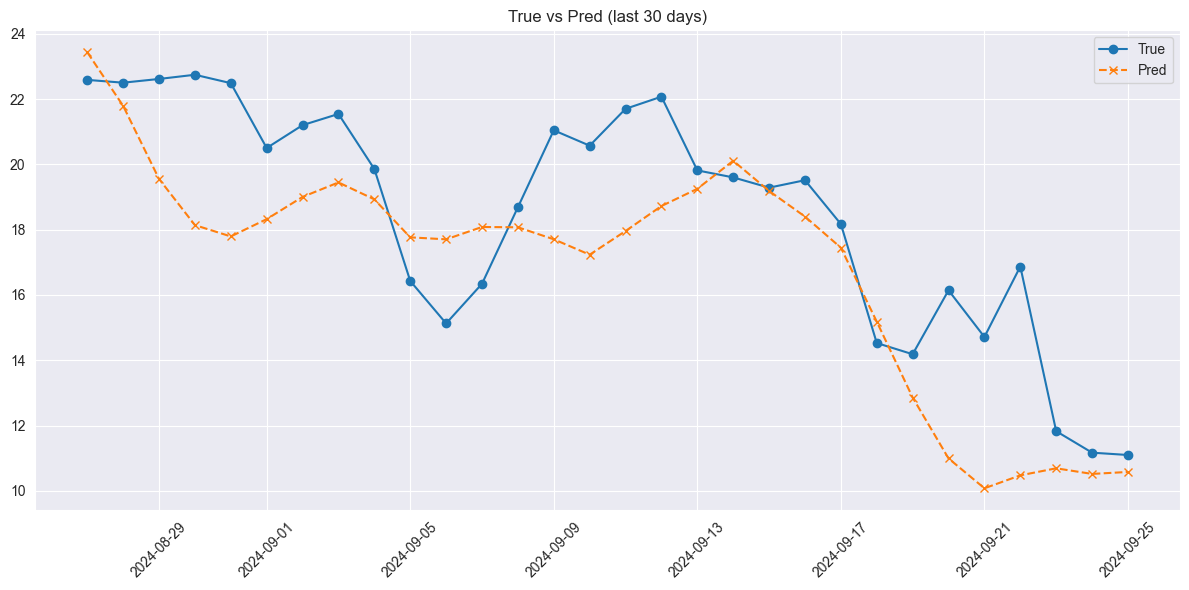

In [338]:
plot_true_vs_pred(test_df, y_lstm, station_ids)

In [339]:
df_metrics = daily_metrics_lstm(test_df, y_pred, station_ids)

df_metrics

,date,MAE,RMSE,R2
0,2024-08-27,1.197633,1.443131,-2.889052
1,2024-08-28,1.005426,1.278276,-1.749500
2,2024-08-29,3.061054,3.289925,-20.350915
3,2024-08-30,4.603950,4.803243,-35.727945
4,2024-08-31,4.693419,4.836731,-17.218443
5,2024-09-01,2.179733,2.467369,-4.477556
6,2024-09-02,2.197240,2.451974,-16.985141
7,2024-09-03,2.218276,2.634980,-18.308328
8,2024-09-04,1.419782,1.822538,-1.643074
9,2024-09-05,1.335696,1.680174,-1.163376


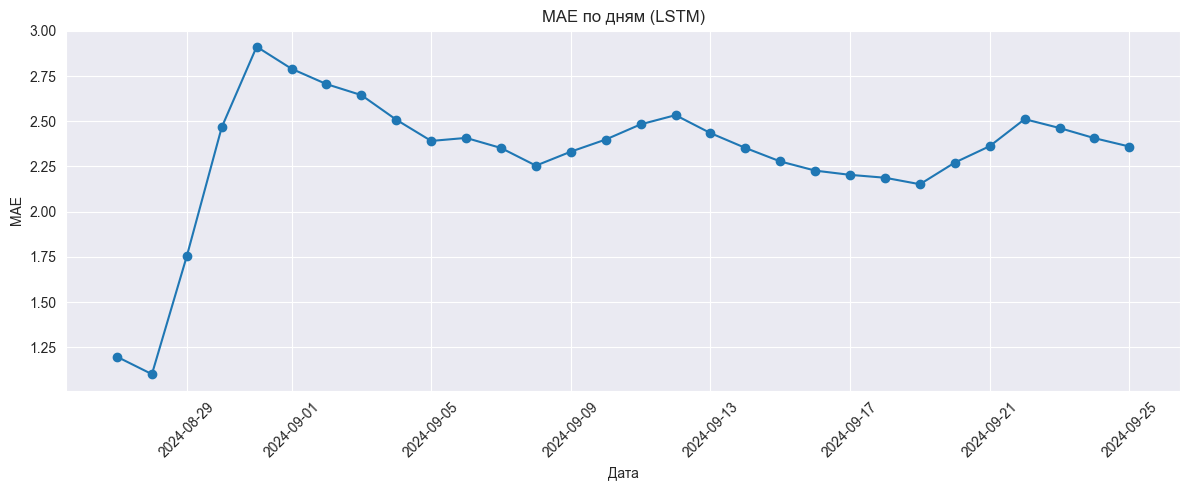

        date  Cumulative_MAE
0 2024-08-27        1.197633
1 2024-08-28        1.101529
2 2024-08-29        1.754704
3 2024-08-30        2.467015
4 2024-08-31        2.912296


In [340]:
cum_df = cumulative_mae_lstm(test_df, y_pred, station_ids)

print(cum_df.head())

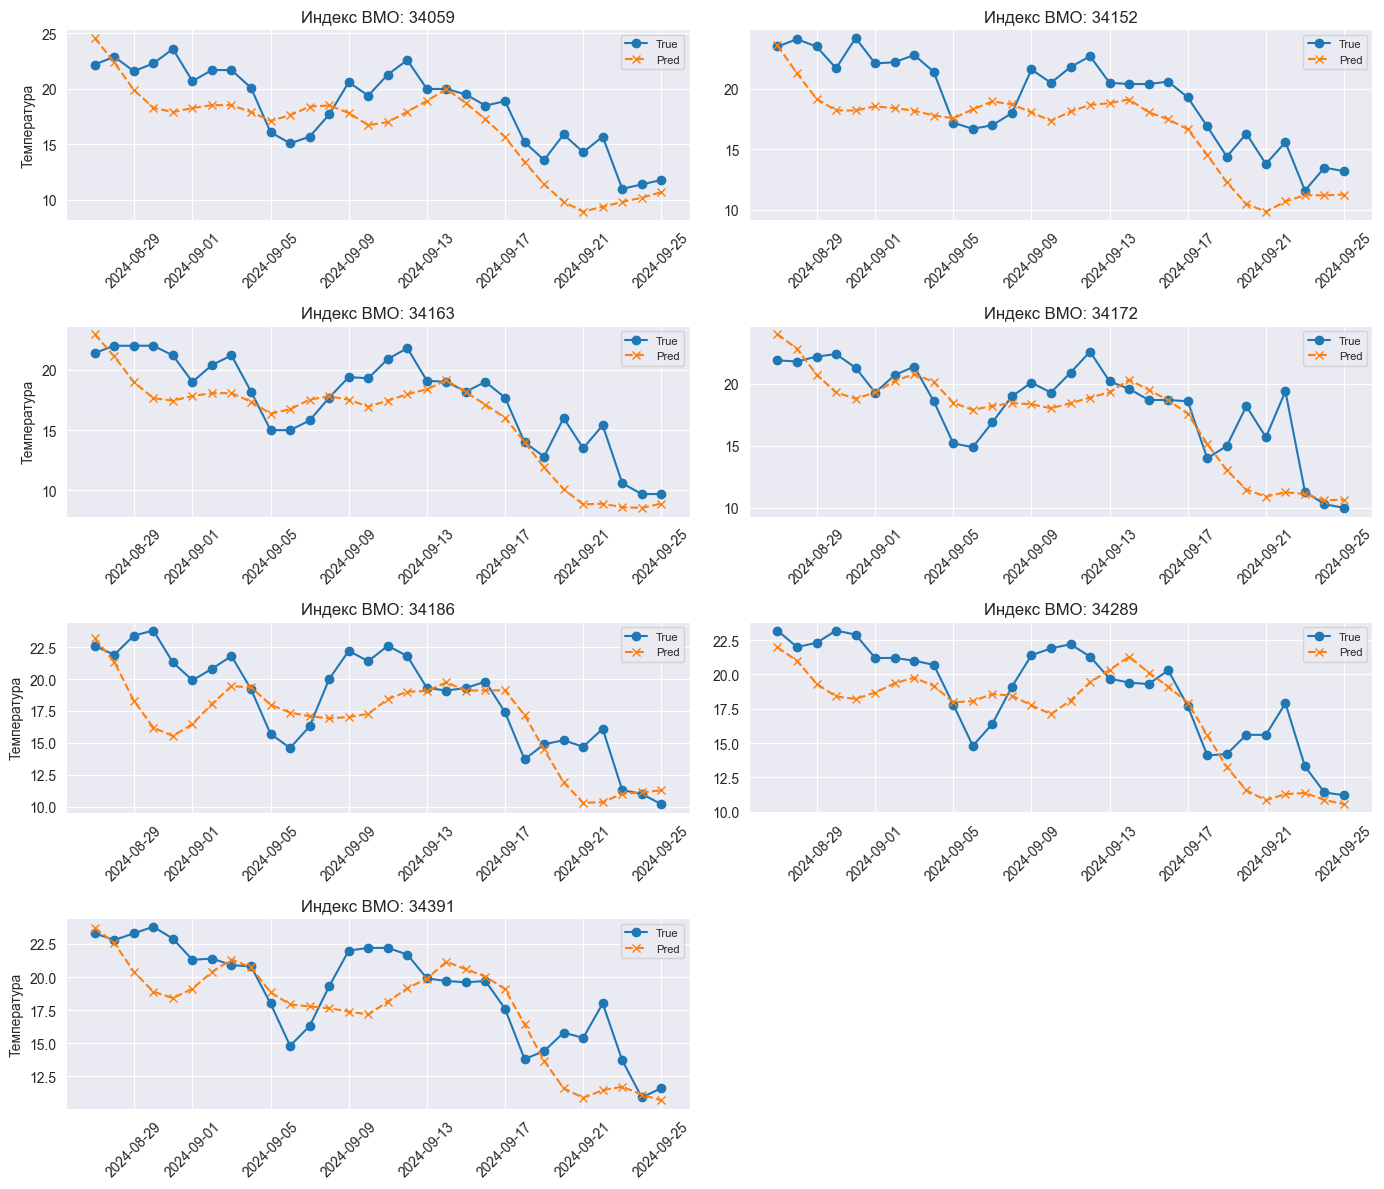

In [341]:
plot_true_vs_pred_by_index(test_df, y_pred, station_ids)

## Ансамбли

### Метрики оценки точности

#### Стандартные методы

In [342]:
def simple_metric(y_val, y_pred):
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_val - y_pred) / y_val)) * 100
    r2 = r2_score(y_val, y_pred)

    print("Простые метрики:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²: {r2:.4f}")
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

#### Ошибки по дням

In [343]:
def daily_metrics(df_val, y_pred, date_col='date',
                  y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    df_val['prediction'] = y_pred
    results = []

    for date, group in df_val.groupby(date_col):
        y_true = group[y_true_col].values
        y_pred = group[y_pred_col].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        results.append({
            'date': date,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    return pd.DataFrame(results).sort_values('date')

#### Столбчатые диаграммы ошибок по индексам

In [344]:
def metrics_per_index(df_val, y_pred, index_col='Индекс ВМО',
                      y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    """
    df_val: DataFrame с колонками y_true и индекс
    y_pred: массив предсказаний
    """
    df_val = df_val.copy()
    df_val[y_pred_col] = y_pred

    metrics_list = []

    for idx, group in df_val.groupby(index_col):
        y_true = group[y_true_col].values
        y_p = group[y_pred_col].values

        mae = mean_absolute_error(y_true, y_p)
        rmse = np.sqrt(mean_squared_error(y_true, y_p))
        r2 = r2_score(y_true, y_p)

        metrics_list.append({
            index_col: idx,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    metrics_df = pd.DataFrame(metrics_list).sort_values(index_col)

    # Строим графики
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    axes[0].bar(metrics_df[index_col].astype(str), metrics_df['MAE'], color='skyblue')
    axes[0].set_title('MAE по индексам')
    axes[0].set_ylabel('MAE (°C)')

    axes[1].bar(metrics_df[index_col].astype(str), metrics_df['RMSE'], color='salmon')
    axes[1].set_title('RMSE по индексам')
    axes[1].set_ylabel('RMSE (°C)')

    axes[2].bar(metrics_df[index_col].astype(str), metrics_df['R2'], color='lightgreen')
    axes[2].set_title('R² по индексам')
    axes[2].set_ylabel('R²')

    for ax in axes:
        ax.set_xlabel('Индекс ВМО')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return metrics_df

#### Линейный график MAE

In [345]:
def cumulative_mae(df_val, y_pred, date_col='date',
                   y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    """
    df_val: DataFrame с колонками y_true и date
    y_pred: массив предсказаний
    """
    df_val = df_val.copy()
    df_val[y_pred_col] = y_pred

    # Сортируем по дате
    df_val = df_val.sort_values(date_col)

    # Копим MAE по дням
    cum_errors = []
    all_true = []
    all_pred = []

    for date, group in df_val.groupby(date_col):
        all_true.extend(group[y_true_col].values)
        all_pred.extend(group[y_pred_col].values)

        mae = mean_absolute_error(all_true, all_pred)
        cum_errors.append({'date': date, 'Cumulative_MAE': mae})

    cum_df = pd.DataFrame(cum_errors)

    # График
    plt.figure(figsize=(12, 5))
    plt.plot(cum_df['date'], cum_df['Cumulative_MAE'], marker='o', linestyle='-')
    plt.xlabel('Дата')
    plt.ylabel('MAE (°C)')
    plt.title('MAE по дням')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    return cum_df

#### Накопление ошибки Mae

In [346]:
def cumulative_error(df_val, y_pred, date_col='date',
                     y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    df_val = df_val.copy()
    df_val[y_pred_col] = y_pred

    df_val = df_val.sort_values(date_col)

    cum_errors = []
    total_error = 0

    for date, group in df_val.groupby(date_col):
        daily_error = (group[y_true_col] - group[y_pred_col]).abs().sum()
        total_error += daily_error

        cum_errors.append({'date': date, 'Cumulative_Error': total_error})

    cum_df = pd.DataFrame(cum_errors)

    # График
    plt.figure(figsize=(12, 5))
    plt.plot(cum_df['date'], cum_df['Cumulative_Error'], marker='o')
    plt.xlabel('Дата')
    plt.ylabel('Накопленная ошибка')
    plt.title('Накопление абсолютной ошибки по дням')
    # plt.xticks(rotation=45)
    plt.xticks(cum_df['date'], rotation=45)
    plt.grid(True)
    plt.show()

    return cum_df

#### Сравнения истинной средней и предсказанной средней

In [347]:
def plot_true_vs_pred(df_val, y_pred, date_col='date', y_true_col='Средняя температура воздуха'):
    df_plot = df_val.copy()
    df_plot['prediction'] = y_pred

    # Усредняем по индексам
    daily_true = df_plot.groupby(date_col)[y_true_col].mean()
    daily_pred = df_plot.groupby(date_col)['prediction'].mean()

    plt.figure(figsize=(12, 6))
    plt.plot(daily_true.index, daily_true.values, label='Истинная температура', marker='o', linestyle='-', color='blue')
    plt.plot(daily_pred.index, daily_pred.values, label='Предсказанная температура', marker='x', linestyle='--',
             color='orange')
    plt.xlabel('Дата')
    plt.ylabel('Температура (°C)')
    plt.title('Сравнение истинной и предсказанной температуры')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Сравнение истинной и предсказанной по индексам

In [348]:
def plot_true_vs_pred_by_index(df_val, y_pred, date_col='date', index_col='Индекс ВМО',
                               y_true_col='Средняя температура воздуха'):
    df_plot = df_val.copy()
    df_plot['prediction'] = y_pred

    indices = df_plot[index_col].unique()
    n_indices = len(indices)

    # Определяем размер подграфиков (по 2 в ряду)
    n_cols = 2
    n_rows = (n_indices + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        ax = axes[i]
        df_idx = df_plot[df_plot[index_col] == idx]
        ax.plot(df_idx[date_col], df_idx[y_true_col], label='Истинная', marker='o', linestyle='-', color='blue')
        ax.plot(df_idx[date_col], df_idx['prediction'], label='Предсказанная', marker='x', linestyle='--',
                color='orange')
        ax.set_title(f'Индекс ВМО: {idx}')
        ax.grid(True, linestyle='--', alpha=0.5)
        if i % n_cols == 0:
            ax.set_ylabel('Температура (°C)')
        ax.legend(fontsize=8)

    # Скрываем лишние пустые графики
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Функция построения лагов

In [349]:
def create_lags(df, lag_cols, lag, group_col='Индекс ВМО', date_col='date'):
    df = df.sort_values([group_col, date_col]).copy()

    # 1. берём только те колонки, которые реально есть
    existing_cols = [col for col in lag_cols if col in df.columns]

    # 2. создаём лаги только для существующих колонок
    for col in existing_cols:
        df[f'{col}_lag_{lag}'] = df.groupby(group_col)[col].shift(lag)

    # 3. удаляем строки, где лаги не получились
    lagged_cols = [f'{c}_lag_{lag}' for c in existing_cols]
    df = df.dropna(subset=lagged_cols)

    return df

### Модель для предсказаний на 1 день

In [350]:
df_for_one.shape

(109053, 57)

In [351]:
df_for_one.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109053 entries, 0 to 109052
Data columns (total 57 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   Индекс ВМО                                      109053 non-null  int64         
 1   date                                            109053 non-null  datetime64[ns]
 2   Средняя температура воздуха                     109053 non-null  float64       
 3   Количество осадков                              109053 non-null  float64       
 4   Горизонтальная дальность видимости              109053 non-null  float64       
 5   Общее количество облачности                     109053 non-null  float64       
 6   Количество облачности нижнего яруса             109053 non-null  float64       
 7   Форма облаков верхнего яруса                    109053 non-null  float64       
 8   Форма облаков среднего яруса      

#### Строим лаги

In [352]:
df_for_one = create_lags(df_for_one, original_cols, lag=1)

In [353]:
df_for_one.columns[50:60]

Index(['day_of_year_sin', 'day_of_year_cos', 'season', 'month_sin',
       'month_cos', 'Средняя температура воздуха_mean_group',
       'temp_delta_vs_all_stations', 'Средняя температура воздуха_lag_1',
       'Количество осадков_lag_1', 'Горизонтальная дальность видимости_lag_1'],
      dtype='object')

In [354]:
df_for_one.isna().sum().sum()

np.int64(0)

In [355]:
df_for_one.tail()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Максимальная скорость ветра_lag_1,Сумма осадков_lag_1,Температура поверхности почвы_lag_1,Парциальное давление водяного пара_lag_1,Относительная влажность воздуха_lag_1,Дефицит насыщения водяного пара_lag_1,Атмосферное давление на уровне станции_lag_1,Атмосферное давление на уровне моря_lag_1,Характеристика барической тенденции_lag_1,Величина барической тенденции_lag_1
109048,34391,2024-09-21,15.4,0.0,97.0,2.250,0.000,0.625,0.125,0.000,...,4.750,0.0,19.1500,8.41250,45.375,11.58750,1015.9500,1018.9125,5.125,0.7375
109049,34391,2024-09-22,18.0,0.0,97.0,0.625,0.375,0.125,0.000,0.125,...,4.875,0.0,19.9375,8.75000,53.750,9.12500,1015.7125,1018.7000,5.125,0.6500
109050,34391,2024-09-23,13.7,0.0,97.0,0.750,0.000,0.625,0.000,0.000,...,8.125,0.0,21.8500,9.40000,45.875,13.03750,1013.0625,1015.9875,5.125,1.0750
109051,34391,2024-09-24,10.9,0.0,97.0,4.875,0.000,1.125,0.000,0.000,...,6.875,0.0,15.7875,4.81125,36.500,10.17875,1019.2625,1022.2750,3.500,0.7375
109052,34391,2024-09-25,11.6,0.0,97.0,0.250,0.000,0.250,0.000,0.000,...,8.375,0.0,12.9875,5.30250,41.625,8.49750,1022.3500,1025.4000,3.875,0.7000


#### Удаляем оригинальные колонки (Чтобы не было утечек)

In [356]:
target_col

'Средняя температура воздуха'

In [357]:
original_cols[:3]

['Средняя температура воздуха',
 'Количество осадков',
 'Горизонтальная дальность видимости']

In [358]:
cols_to_drop = [
    col for col in original_cols
    if col in df_for_one.columns
       and col != target_col
       and not col.endswith('_missing')
]

df_for_one = df_for_one.drop(columns=cols_to_drop)

In [359]:
df_for_one.shape

(109046, 58)

#### Разделение данных

In [360]:
df_for_one.date.min(), df_for_one.date.max(),

(Timestamp('1982-02-01 00:00:00'), Timestamp('2024-09-25 00:00:00'))

In [361]:
test_start

Timestamp('2024-08-26 00:00:00')

1 месяц на тест

In [362]:
train_df = df_for_one[df_for_one['date'] < test_start].copy()
test_df = df_for_one[df_for_one['date'] >= test_start].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (108829, 58)
Test shape: (217, 58)


In [363]:
test_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Средняя температура воздуха_lag_335,Средняя температура воздуха_lag_365,Средняя температура воздуха_lag_395,Температура поверхности почвы_lag_335,Температура поверхности почвы_lag_365,Температура поверхности почвы_lag_395,Парциальное давление водяного пара_lag_335,...,Максимальная скорость ветра_lag_1,Сумма осадков_lag_1,Температура поверхности почвы_lag_1,Парциальное давление водяного пара_lag_1,Относительная влажность воздуха_lag_1,Дефицит насыщения водяного пара_lag_1,Атмосферное давление на уровне станции_lag_1,Атмосферное давление на уровне моря_lag_1,Характеристика барической тенденции_lag_1,Величина барической тенденции_lag_1
15548,34059,2024-08-26,21.6,17.5,15.5,26.8,19.0250,17.7750,32.1500,12.62500,...,5.625,0.0,30.4625,14.2875,53.250,14.1000,1000.4750,1019.0250,4.250,0.6250
15549,34059,2024-08-27,22.2,15.5,16.0,21.9,18.3125,17.8000,23.1250,11.32500,...,5.250,0.0,28.7000,13.3000,55.000,13.5750,1001.2250,1019.9250,4.125,0.5625
15550,34059,2024-08-28,22.9,13.3,13.0,18.8,16.5875,18.9625,19.9375,8.71250,...,5.250,0.0,29.2500,12.8750,49.875,15.5000,1004.0750,1022.7625,4.125,0.6375
15551,34059,2024-08-29,21.6,13.6,14.2,20.2,18.0000,21.7250,25.5750,10.52375,...,4.250,0.0,29.3500,10.7000,42.375,17.9375,1005.4375,1024.1375,4.875,0.6125
15552,34059,2024-08-30,22.3,15.2,17.1,21.3,18.7125,24.9875,30.1750,10.60125,...,3.375,0.0,26.9000,10.3750,44.500,16.9750,1004.6125,1023.4125,4.750,0.5125


In [364]:
train_df = train_df.drop(columns=['date'])
test_df_drop_date = test_df.drop(columns=['date'])

#### Отделяем целевой признак

In [365]:
y_train = train_df['Средняя температура воздуха']
y_test = test_df_drop_date['Средняя температура воздуха']

# Признаки (оставляем Индекс ВМО)
X_train = train_df.drop(columns=['Средняя температура воздуха'])
X_test = test_df_drop_date.drop(columns=['Средняя температура воздуха'])

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (108829, 56) (108829,)
Test shape: (217, 56) (217,)


In [366]:
print(X_train.isna().sum().sum())
print(y_train.isna().sum().sum())
print('Тест:')
print(X_test.isna().sum().sum())
print(y_test.isna().sum().sum())

0
0
Тест:
0
0


In [367]:
X_train.columns

Index(['Индекс ВМО', 'Средняя температура воздуха_lag_335',
       'Средняя температура воздуха_lag_365',
       'Средняя температура воздуха_lag_395',
       'Температура поверхности почвы_lag_335',
       'Температура поверхности почвы_lag_365',
       'Температура поверхности почвы_lag_395',
       'Парциальное давление водяного пара_lag_335',
       'Парциальное давление водяного пара_lag_365',
       'Парциальное давление водяного пара_lag_395',
       'Относительная влажность воздуха_lag_335',
       'Относительная влажность воздуха_lag_365',
       'Относительная влажность воздуха_lag_395',
       'Дефицит насыщения водяного пара_lag_335',
       'Дефицит насыщения водяного пара_lag_365',
       'Дефицит насыщения водяного пара_lag_395',
       'Атмосферное давление на уровне моря_lag_335',
       'Атмосферное давление на уровне моря_lag_365',
       'Атмосферное давление на уровне моря_lag_395',
       'Атмосферное давление на уровне станции_lag_335',
       'Атмосферное давлен

#### Построение модели

In [368]:
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

params = {'objective': 'regression',
          'metric': 'rmse',
          'seed': 42,
          'verbosity': -1,
          'learning_rate': 0.1,
          'max_depth': 8,
          'min_data_in_leaf': 20,
          'feature_fraction': 0.8,
          'bagging_fraction': 0.7,
          'min_gain_to_split': 0}

model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'test'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20),
        lgb.log_evaluation(period=50)
    ]
)

# Предсказание
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# Метрика
lgb_result = simple_metric(y_test, y_pred)
lgb_result

Training until validation scores don't improve for 20 rounds
[50]	train's rmse: 2.1193	test's rmse: 1.64497
Early stopping, best iteration is:
[32]	train's rmse: 2.26379	test's rmse: 1.63955
Простые метрики:
MAE: 1.2495
MSE: 2.6881
RMSE: 1.6395
MAPE: 7.59%
R²: 0.7960


{'MAE': 1.249476984044896,
 'MSE': 2.688113685367626,
 'RMSE': np.float64(1.639546792674008),
 'MAPE': np.float64(7.59225322171525),
 'R2': 0.7959795006116458}

                                         feature    importance
48           Температура поверхности почвы_lag_1  7.529359e+07
31             Средняя температура воздуха_lag_1  9.084911e+06
49      Парциальное давление водяного пара_lag_1  1.642525e+06
29        Средняя температура воздуха_mean_group  1.188055e+06
51         Дефицит насыщения водяного пара_lag_1  5.310111e+05
54     Характеристика барической тенденции_lag_1  2.609129e+05
53     Атмосферное давление на уровне моря_lag_1  9.960739e+04
25                               day_of_year_cos  8.723673e+04
55           Величина барической тенденции_lag_1  7.830008e+04
32                      Количество осадков_lag_1  4.420226e+04
44                       Направление ветра_lag_1  3.395862e+04
47                           Сумма осадков_lag_1  2.659919e+04
42                    Погода между сроками_lag_1  2.583974e+04
46             Максимальная скорость ветра_lag_1  2.318331e+04
34             Общее количество облачности_lag_1  1.187

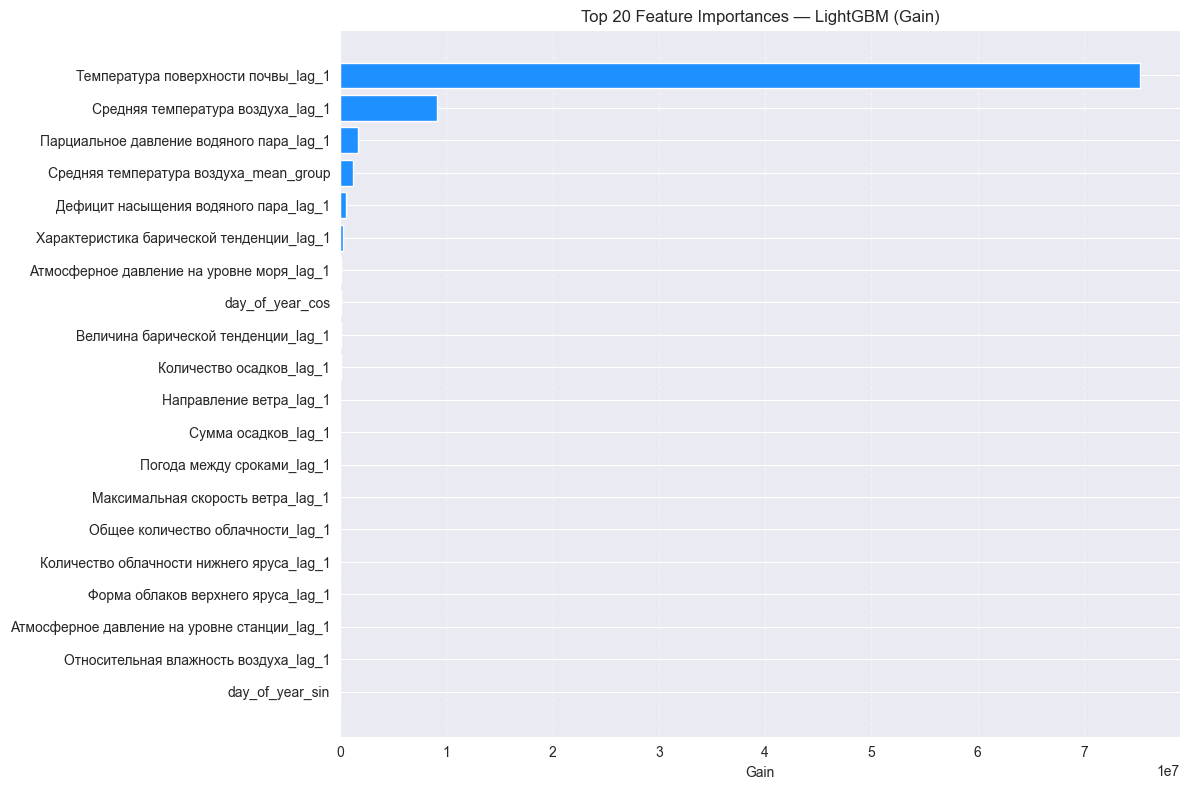

In [369]:
# Получаем важность по gain
gain_importances = model.feature_importance(importance_type='gain')
feature_names = X_train.columns

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': gain_importances
}).sort_values(by='importance', ascending=False)

# Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

plt.figure(figsize=(12, 8))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='dodgerblue')
plt.xlabel('Gain')
plt.title('Top 20 Feature Importances — LightGBM (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Сохранение результата и оценка точности

In [370]:
pred_for_one = y_pred.copy()

In [371]:
first_date = test_df['date'].min()
first_date

Timestamp('2024-08-26 00:00:00')

In [372]:
mask = test_df['date'] == first_date

y_pred_first_day = y_pred[mask]
y_true_first_day = y_test[mask]

In [373]:
simple_metric(y_pred_first_day, y_true_first_day)

Простые метрики:
MAE: 0.9515
MSE: 1.1642
RMSE: 1.0790
MAPE: 4.32%
R²: 0.0038


{'MAE': 0.9514873787618099,
 'MSE': 1.1642162048055078,
 'RMSE': np.float64(1.0789885100433219),
 'MAPE': np.float64(4.317548330628905),
 'R2': 0.0037910054231076185}

### Модель для предсказаний на 2 дня

In [374]:
df_for_two.shape

(109053, 57)

#### Строим лаги

In [375]:
df_for_two = create_lags(df_for_two, original_cols, lag=2)

In [376]:
df_for_two.columns[50:60]

Index(['day_of_year_sin', 'day_of_year_cos', 'season', 'month_sin',
       'month_cos', 'Средняя температура воздуха_mean_group',
       'temp_delta_vs_all_stations', 'Средняя температура воздуха_lag_2',
       'Количество осадков_lag_2', 'Горизонтальная дальность видимости_lag_2'],
      dtype='object')

In [377]:
df_for_two.isna().sum().sum()

np.int64(0)

#### Удаляем оригинальные колонки (Чтобы не было утечек)

In [378]:
target_col

'Средняя температура воздуха'

In [379]:
original_cols[:3]

['Средняя температура воздуха',
 'Количество осадков',
 'Горизонтальная дальность видимости']

In [380]:
cols_to_drop = [
    col for col in original_cols
    if col in df_for_two.columns
       and col != target_col
       and not col.endswith('_missing')
]

df_for_two = df_for_two.drop(columns=cols_to_drop)

In [381]:
df_for_two.shape

(109039, 58)

#### Разделение данных

In [382]:
df_for_two.date.min(), df_for_two.date.max(),

(Timestamp('1982-02-02 00:00:00'), Timestamp('2024-09-25 00:00:00'))

In [383]:
test_start

Timestamp('2024-08-26 00:00:00')

1 месяц на тест

In [384]:
train_df = df_for_two[df_for_two['date'] < test_start].copy()
test_df = df_for_two[df_for_two['date'] >= test_start].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (108822, 58)
Test shape: (217, 58)


In [385]:
test_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Средняя температура воздуха_lag_335,Средняя температура воздуха_lag_365,Средняя температура воздуха_lag_395,Температура поверхности почвы_lag_335,Температура поверхности почвы_lag_365,Температура поверхности почвы_lag_395,Парциальное давление водяного пара_lag_335,...,Максимальная скорость ветра_lag_2,Сумма осадков_lag_2,Температура поверхности почвы_lag_2,Парциальное давление водяного пара_lag_2,Относительная влажность воздуха_lag_2,Дефицит насыщения водяного пара_lag_2,Атмосферное давление на уровне станции_lag_2,Атмосферное давление на уровне моря_lag_2,Характеристика барической тенденции_lag_2,Величина барической тенденции_lag_2
15548,34059,2024-08-26,21.6,17.5,15.5,26.8,19.0250,17.7750,32.1500,12.62500,...,5.250,0.0,29.9375,12.2625,44.500,18.0250,999.5875,1018.1125,4.375,0.5000
15549,34059,2024-08-27,22.2,15.5,16.0,21.9,18.3125,17.8000,23.1250,11.32500,...,5.625,0.0,30.4625,14.2875,53.250,14.1000,1000.4750,1019.0250,4.250,0.6250
15550,34059,2024-08-28,22.9,13.3,13.0,18.8,16.5875,18.9625,19.9375,8.71250,...,5.250,0.0,28.7000,13.3000,55.000,13.5750,1001.2250,1019.9250,4.125,0.5625
15551,34059,2024-08-29,21.6,13.6,14.2,20.2,18.0000,21.7250,25.5750,10.52375,...,5.250,0.0,29.2500,12.8750,49.875,15.5000,1004.0750,1022.7625,4.125,0.6375
15552,34059,2024-08-30,22.3,15.2,17.1,21.3,18.7125,24.9875,30.1750,10.60125,...,4.250,0.0,29.3500,10.7000,42.375,17.9375,1005.4375,1024.1375,4.875,0.6125


In [386]:
train_df = train_df.drop(columns=['date'])
test_df_drop_date = test_df.drop(columns=['date'])

#### Отделяем целевой признак

In [387]:
y_train = train_df['Средняя температура воздуха']
y_test = test_df_drop_date['Средняя температура воздуха']

# Признаки (оставляем Индекс ВМО)
X_train = train_df.drop(columns=['Средняя температура воздуха'])
X_test = test_df_drop_date.drop(columns=['Средняя температура воздуха'])

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (108822, 56) (108822,)
Test shape: (217, 56) (217,)


In [388]:
print(X_train.isna().sum().sum())
print(y_train.isna().sum().sum())
print('Тест:')
print(X_test.isna().sum().sum())
print(y_test.isna().sum().sum())

0
0
Тест:
0
0


#### Построение модели

In [389]:
# Создаем DMatrix для XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {'objective': 'reg:squarederror',
          'eval_metric': 'rmse',
          'seed': 42,
          'eta': 0.03,
          'max_depth': 8,
          'min_child_weight': 1,
          'subsample': 0.7,
          'colsample_bytree': 0.8,
          'gamma': 0.1}

evals = [(dtrain, 'train'), (dtest, 'test')]
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50
)

# Предсказание на тесте
y_pred = xgb_model.predict(dtest)
xgb_result = simple_metric(y_test, y_pred)
xgb_result

[0]	train-rmse:12.28821	test-rmse:11.87664
[50]	train-rmse:4.24842	test-rmse:3.16645
[100]	train-rmse:3.16261	test-rmse:2.26082
[149]	train-rmse:2.93586	test-rmse:2.26646
Простые метрики:
MAE: 1.7510
MSE: 5.1368
RMSE: 2.2665
MAPE: 10.65%
R²: 0.6101


{'MAE': 1.751015642930835,
 'MSE': 5.136839158530813,
 'RMSE': np.float64(2.266459608846099),
 'MAPE': np.float64(10.652819291311562),
 'R2': 0.6101279138208091}

                                         feature    importance
48           Температура поверхности почвы_lag_2  7.529359e+07
31             Средняя температура воздуха_lag_2  9.084911e+06
49      Парциальное давление водяного пара_lag_2  1.642525e+06
29        Средняя температура воздуха_mean_group  1.188055e+06
51         Дефицит насыщения водяного пара_lag_2  5.310111e+05
54     Характеристика барической тенденции_lag_2  2.609129e+05
53     Атмосферное давление на уровне моря_lag_2  9.960739e+04
25                               day_of_year_cos  8.723673e+04
55           Величина барической тенденции_lag_2  7.830008e+04
32                      Количество осадков_lag_2  4.420226e+04
44                       Направление ветра_lag_2  3.395862e+04
47                           Сумма осадков_lag_2  2.659919e+04
42                    Погода между сроками_lag_2  2.583974e+04
46             Максимальная скорость ветра_lag_2  2.318331e+04
34             Общее количество облачности_lag_2  1.187

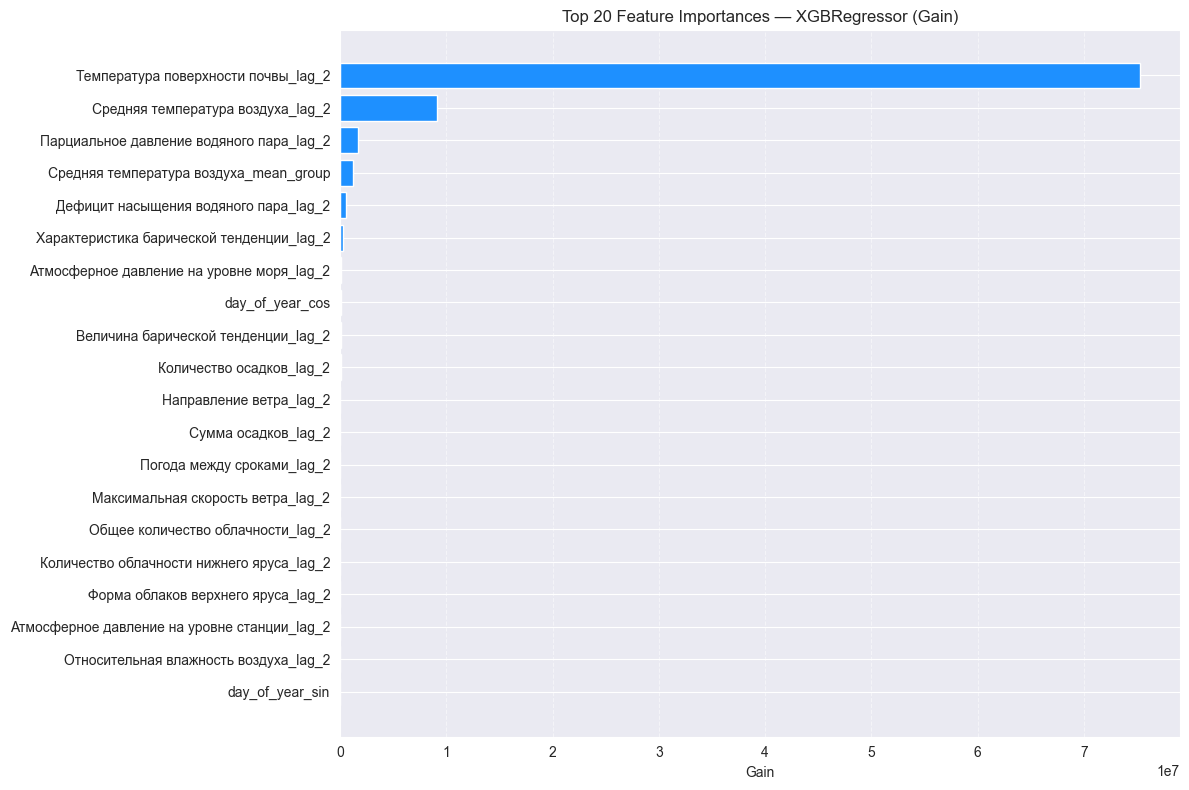

In [390]:
# Получаем важность по gain
gain_importances = model.feature_importance(importance_type='gain')
feature_names = X_train.columns

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': gain_importances
}).sort_values(by='importance', ascending=False)

# Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

plt.figure(figsize=(12, 8))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='dodgerblue')
plt.xlabel('Gain')
plt.title('Top 20 Feature Importances — XGBRegressor (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Сохранение результата и оценка точности

In [391]:
pred_for_two = y_pred.copy()

In [392]:
second_date = first_date + pd.Timedelta(days=1)

In [393]:
mask = test_df['date'] == second_date

y_pred_second_day = y_pred[mask]
y_true_second_day = y_test[mask]

In [394]:
simple_metric(y_pred_second_day, y_true_second_day)

Простые метрики:
MAE: 1.1382
MSE: 1.7324
RMSE: 1.3162
MAPE: 5.25%
R²: -2.1222


{'MAE': 1.138151713779995,
 'MSE': 1.7324025311697515,
 'RMSE': np.float64(1.316207632241111),
 'MAPE': np.float64(5.246227187446319),
 'R2': -2.12219371190314}

### Модель для предсказаний на 3 дня

In [395]:
df_for_three.shape

(109053, 57)

#### Строим лаги

In [396]:
df_for_three = create_lags(df_for_three, original_cols, lag=3)

In [397]:
df_for_three.columns[50:60]

Index(['day_of_year_sin', 'day_of_year_cos', 'season', 'month_sin',
       'month_cos', 'Средняя температура воздуха_mean_group',
       'temp_delta_vs_all_stations', 'Средняя температура воздуха_lag_3',
       'Количество осадков_lag_3', 'Горизонтальная дальность видимости_lag_3'],
      dtype='object')

In [398]:
df_for_three.isna().sum().sum()

np.int64(0)

#### Удаляем оригинальные колонки (Чтобы не было утечек)

In [399]:
target_col

'Средняя температура воздуха'

In [400]:
original_cols[:3]

['Средняя температура воздуха',
 'Количество осадков',
 'Горизонтальная дальность видимости']

In [401]:
cols_to_drop = [
    col for col in original_cols
    if col in df_for_three.columns
       and col != target_col
       and not col.endswith('_missing')
]

df_for_three = df_for_three.drop(columns=cols_to_drop)

In [402]:
df_for_three.shape

(109032, 58)

#### Разделение данных

In [403]:
df_for_three.date.min(), df_for_three.date.max(),

(Timestamp('1982-02-03 00:00:00'), Timestamp('2024-09-25 00:00:00'))

In [404]:
test_start

Timestamp('2024-08-26 00:00:00')

1 месяц на тест

In [405]:
train_df = df_for_three[df_for_three['date'] < test_start].copy()
test_df = df_for_three[df_for_three['date'] >= test_start].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (108815, 58)
Test shape: (217, 58)


In [406]:
test_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Средняя температура воздуха_lag_335,Средняя температура воздуха_lag_365,Средняя температура воздуха_lag_395,Температура поверхности почвы_lag_335,Температура поверхности почвы_lag_365,Температура поверхности почвы_lag_395,Парциальное давление водяного пара_lag_335,...,Максимальная скорость ветра_lag_3,Сумма осадков_lag_3,Температура поверхности почвы_lag_3,Парциальное давление водяного пара_lag_3,Относительная влажность воздуха_lag_3,Дефицит насыщения водяного пара_lag_3,Атмосферное давление на уровне станции_lag_3,Атмосферное давление на уровне моря_lag_3,Характеристика барической тенденции_lag_3,Величина барической тенденции_lag_3
15548,34059,2024-08-26,21.6,17.5,15.5,26.8,19.0250,17.7750,32.1500,12.62500,...,5.250,0.0,29.1875,10.8000,45.875,15.5375,997.7000,1016.3750,3.750,0.5625
15549,34059,2024-08-27,22.2,15.5,16.0,21.9,18.3125,17.8000,23.1250,11.32500,...,5.250,0.0,29.9375,12.2625,44.500,18.0250,999.5875,1018.1125,4.375,0.5000
15550,34059,2024-08-28,22.9,13.3,13.0,18.8,16.5875,18.9625,19.9375,8.71250,...,5.625,0.0,30.4625,14.2875,53.250,14.1000,1000.4750,1019.0250,4.250,0.6250
15551,34059,2024-08-29,21.6,13.6,14.2,20.2,18.0000,21.7250,25.5750,10.52375,...,5.250,0.0,28.7000,13.3000,55.000,13.5750,1001.2250,1019.9250,4.125,0.5625
15552,34059,2024-08-30,22.3,15.2,17.1,21.3,18.7125,24.9875,30.1750,10.60125,...,5.250,0.0,29.2500,12.8750,49.875,15.5000,1004.0750,1022.7625,4.125,0.6375


In [407]:
train_df = train_df.drop(columns=['date'])
test_df_drop_date = test_df.drop(columns=['date'])

#### Отделяем целевой признак

In [408]:
y_train = train_df['Средняя температура воздуха']
y_test = test_df_drop_date['Средняя температура воздуха']

# Признаки (оставляем Индекс ВМО)
X_train = train_df.drop(columns=['Средняя температура воздуха'])
X_test = test_df_drop_date.drop(columns=['Средняя температура воздуха'])

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (108815, 56) (108815,)
Test shape: (217, 56) (217,)


In [409]:
print(X_train.isna().sum().sum())
print(y_train.isna().sum().sum())
print('Тест:')
print(X_test.isna().sum().sum())
print(y_test.isna().sum().sum())

0
0
Тест:
0
0


#### Построение модели

In [410]:
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

params = {'objective': 'regression',
          'metric': 'rmse',
          'seed': 42,
          'verbosity': -1,
          'learning_rate': 0.1,
          'max_depth': 8,
          'min_data_in_leaf': 20,
          'feature_fraction': 0.8,
          'bagging_fraction': 0.7,
          'min_gain_to_split': 0}

model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'test'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20),
        lgb.log_evaluation(period=50)
    ]
)

# Предсказание
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# Метрика
lgb_result = simple_metric(y_test, y_pred)
lgb_result

Training until validation scores don't improve for 20 rounds
[50]	train's rmse: 3.86156	test's rmse: 2.58401
Early stopping, best iteration is:
[38]	train's rmse: 3.94339	test's rmse: 2.52876
Простые метрики:
MAE: 2.0232
MSE: 6.3946
RMSE: 2.5288
MAPE: 12.37%
R²: 0.5147


{'MAE': 2.0231695908927665,
 'MSE': 6.3946085558388,
 'RMSE': np.float64(2.5287563259117714),
 'MAPE': np.float64(12.370989441449096),
 'R2': 0.5146666459618678}

                                         feature    importance
48           Температура поверхности почвы_lag_3  3.863461e+07
29        Средняя температура воздуха_mean_group  3.678649e+07
31             Средняя температура воздуха_lag_3  3.424629e+06
25                               day_of_year_cos  7.470972e+05
53     Атмосферное давление на уровне моря_lag_3  5.180983e+05
49      Парциальное давление водяного пара_lag_3  4.825837e+05
54     Характеристика барической тенденции_lag_3  2.174790e+05
22                                          year  2.084959e+05
26                                        season  1.966983e+05
28                                     month_cos  1.789841e+05
51         Дефицит насыщения водяного пара_lag_3  1.724891e+05
24                               day_of_year_sin  1.658662e+05
44                       Направление ветра_lag_3  1.420381e+05
5          Температура поверхности почвы_lag_365  6.012556e+04
52  Атмосферное давление на уровне станции_lag_3  5.158

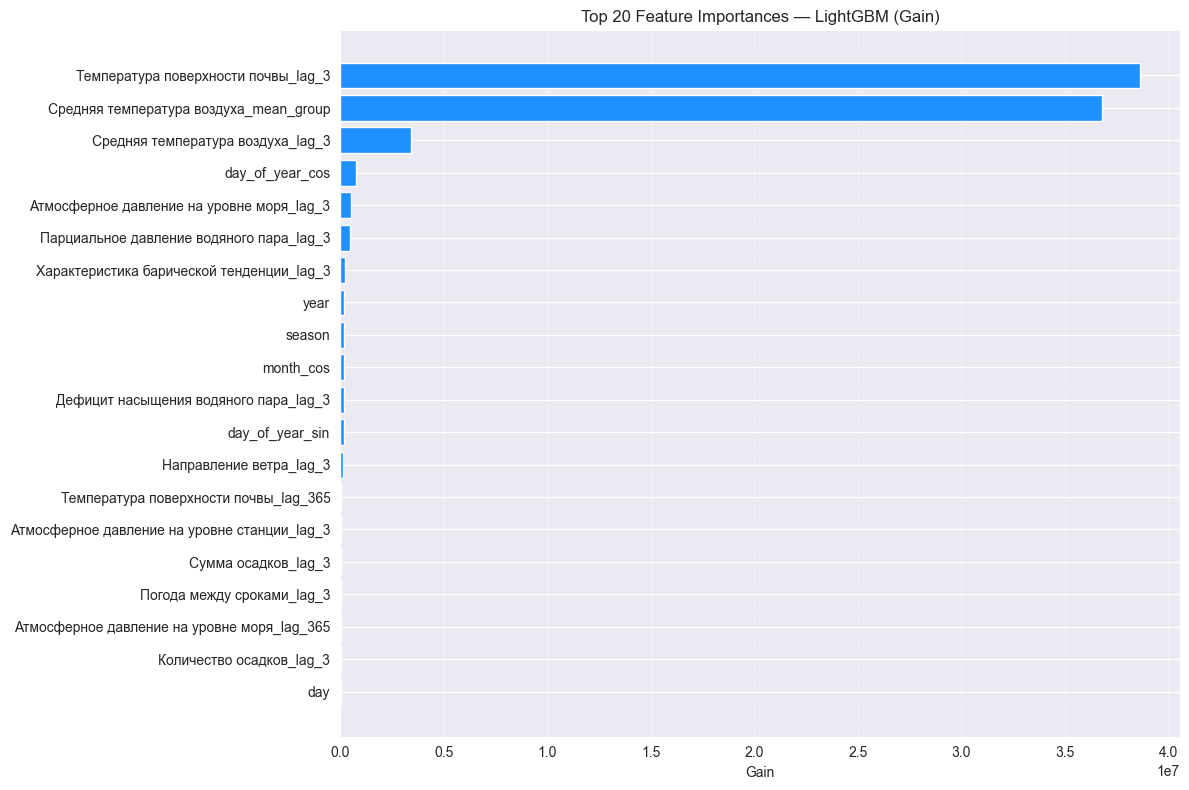

In [411]:
# Получаем важность по gain
gain_importances = model.feature_importance(importance_type='gain')
feature_names = X_train.columns

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': gain_importances
}).sort_values(by='importance', ascending=False)

# Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

plt.figure(figsize=(12, 8))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='dodgerblue')
plt.xlabel('Gain')
plt.title('Top 20 Feature Importances — LightGBM (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Сохранение результата и оценка точности

In [412]:
pred_for_three = y_pred.copy()

In [413]:
third_date = first_date + pd.Timedelta(days=2)

In [414]:
mask = test_df['date'] == third_date

y_pred_third_day = y_pred[mask]
y_true_third_day = y_test[mask]

In [415]:
simple_metric(y_pred_first_day, y_true_first_day)

Простые метрики:
MAE: 0.9515
MSE: 1.1642
RMSE: 1.0790
MAPE: 4.32%
R²: 0.0038


{'MAE': 0.9514873787618099,
 'MSE': 1.1642162048055078,
 'RMSE': np.float64(1.0789885100433219),
 'MAPE': np.float64(4.317548330628905),
 'R2': 0.0037910054231076185}

### Модель для предсказаний на 4 дня

In [416]:
df_for_four.shape

(109053, 57)

#### Строим лаги

In [417]:
df_for_four = create_lags(df_for_four, original_cols, lag=4)

In [418]:
df_for_four.columns[50:60]

Index(['day_of_year_sin', 'day_of_year_cos', 'season', 'month_sin',
       'month_cos', 'Средняя температура воздуха_mean_group',
       'temp_delta_vs_all_stations', 'Средняя температура воздуха_lag_4',
       'Количество осадков_lag_4', 'Горизонтальная дальность видимости_lag_4'],
      dtype='object')

In [419]:
df_for_four.isna().sum().sum()

np.int64(0)

#### Удаляем оригинальные колонки (Чтобы не было утечек)

In [420]:
target_col

'Средняя температура воздуха'

In [421]:
original_cols[:3]

['Средняя температура воздуха',
 'Количество осадков',
 'Горизонтальная дальность видимости']

In [422]:
cols_to_drop = [
    col for col in original_cols
    if col in df_for_four.columns
       and col != target_col
       and not col.endswith('_missing')
]

df_for_four = df_for_four.drop(columns=cols_to_drop)

In [423]:
df_for_four.shape

(109025, 58)

#### Разделение данных

In [424]:
df_for_four.date.min(), df_for_four.date.max(),

(Timestamp('1982-02-04 00:00:00'), Timestamp('2024-09-25 00:00:00'))

In [425]:
test_start

Timestamp('2024-08-26 00:00:00')

1 месяц на тест

In [426]:
train_df = df_for_four[df_for_four['date'] < test_start].copy()
test_df = df_for_four[df_for_four['date'] >= test_start].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (108808, 58)
Test shape: (217, 58)


In [427]:
test_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Средняя температура воздуха_lag_335,Средняя температура воздуха_lag_365,Средняя температура воздуха_lag_395,Температура поверхности почвы_lag_335,Температура поверхности почвы_lag_365,Температура поверхности почвы_lag_395,Парциальное давление водяного пара_lag_335,...,Максимальная скорость ветра_lag_4,Сумма осадков_lag_4,Температура поверхности почвы_lag_4,Парциальное давление водяного пара_lag_4,Относительная влажность воздуха_lag_4,Дефицит насыщения водяного пара_lag_4,Атмосферное давление на уровне станции_lag_4,Атмосферное давление на уровне моря_lag_4,Характеристика барической тенденции_lag_4,Величина барической тенденции_lag_4
15548,34059,2024-08-26,21.6,17.5,15.5,26.8,19.0250,17.7750,32.1500,12.62500,...,6.375,0.0,28.7750,11.0875,48.250,13.9000,995.9375,1014.6125,4.750,0.4125
15549,34059,2024-08-27,22.2,15.5,16.0,21.9,18.3125,17.8000,23.1250,11.32500,...,5.250,0.0,29.1875,10.8000,45.875,15.5375,997.7000,1016.3750,3.750,0.5625
15550,34059,2024-08-28,22.9,13.3,13.0,18.8,16.5875,18.9625,19.9375,8.71250,...,5.250,0.0,29.9375,12.2625,44.500,18.0250,999.5875,1018.1125,4.375,0.5000
15551,34059,2024-08-29,21.6,13.6,14.2,20.2,18.0000,21.7250,25.5750,10.52375,...,5.625,0.0,30.4625,14.2875,53.250,14.1000,1000.4750,1019.0250,4.250,0.6250
15552,34059,2024-08-30,22.3,15.2,17.1,21.3,18.7125,24.9875,30.1750,10.60125,...,5.250,0.0,28.7000,13.3000,55.000,13.5750,1001.2250,1019.9250,4.125,0.5625


In [428]:
train_df = train_df.drop(columns=['date'])
test_df_drop_date = test_df.drop(columns=['date'])

#### Отделяем целевой признак

In [429]:
y_train = train_df['Средняя температура воздуха']
y_test = test_df_drop_date['Средняя температура воздуха']

# Признаки (оставляем Индекс ВМО)
X_train = train_df.drop(columns=['Средняя температура воздуха'])
X_test = test_df_drop_date.drop(columns=['Средняя температура воздуха'])

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (108808, 56) (108808,)
Test shape: (217, 56) (217,)


In [430]:
print(X_train.isna().sum().sum())
print(y_train.isna().sum().sum())
print('Тест:')
print(X_test.isna().sum().sum())
print(y_test.isna().sum().sum())

0
0
Тест:
0
0


#### Построение модели

In [431]:
# Создаем DMatrix для XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {'objective': 'reg:squarederror',
          'eval_metric': 'rmse',
          'seed': 42,
          'eta': 0.1,
          'max_depth': 4,
          'min_child_weight': 1,
          'subsample': 0.8,
          'colsample_bytree': 0.8,
          'gamma': 0}

evals = [(dtrain, 'train'), (dtest, 'test')]
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50
)

# Предсказание на тесте
y_pred = xgb_model.predict(dtest)
xgb_result = simple_metric(y_test, y_pred)
xgb_result

[0]	train-rmse:11.55447	test-rmse:11.23008
[50]	train-rmse:4.28312	test-rmse:2.63833
[100]	train-rmse:4.15421	test-rmse:2.59994
[150]	train-rmse:4.05997	test-rmse:2.59618
[200]	train-rmse:3.97433	test-rmse:2.59849
[241]	train-rmse:3.92147	test-rmse:2.60027
Простые метрики:
MAE: 2.1290
MSE: 6.7614
RMSE: 2.6003
MAPE: 12.46%
R²: 0.4868


{'MAE': 2.128966109983383,
 'MSE': 6.7614092115100535,
 'RMSE': np.float64(2.600270988091444),
 'MAPE': np.float64(12.46117032540784),
 'R2': 0.48682747630420853}

                                         feature    importance
48           Температура поверхности почвы_lag_4  3.863461e+07
29        Средняя температура воздуха_mean_group  3.678649e+07
31             Средняя температура воздуха_lag_4  3.424629e+06
25                               day_of_year_cos  7.470972e+05
53     Атмосферное давление на уровне моря_lag_4  5.180983e+05
49      Парциальное давление водяного пара_lag_4  4.825837e+05
54     Характеристика барической тенденции_lag_4  2.174790e+05
22                                          year  2.084959e+05
26                                        season  1.966983e+05
28                                     month_cos  1.789841e+05
51         Дефицит насыщения водяного пара_lag_4  1.724891e+05
24                               day_of_year_sin  1.658662e+05
44                       Направление ветра_lag_4  1.420381e+05
5          Температура поверхности почвы_lag_365  6.012556e+04
52  Атмосферное давление на уровне станции_lag_4  5.158

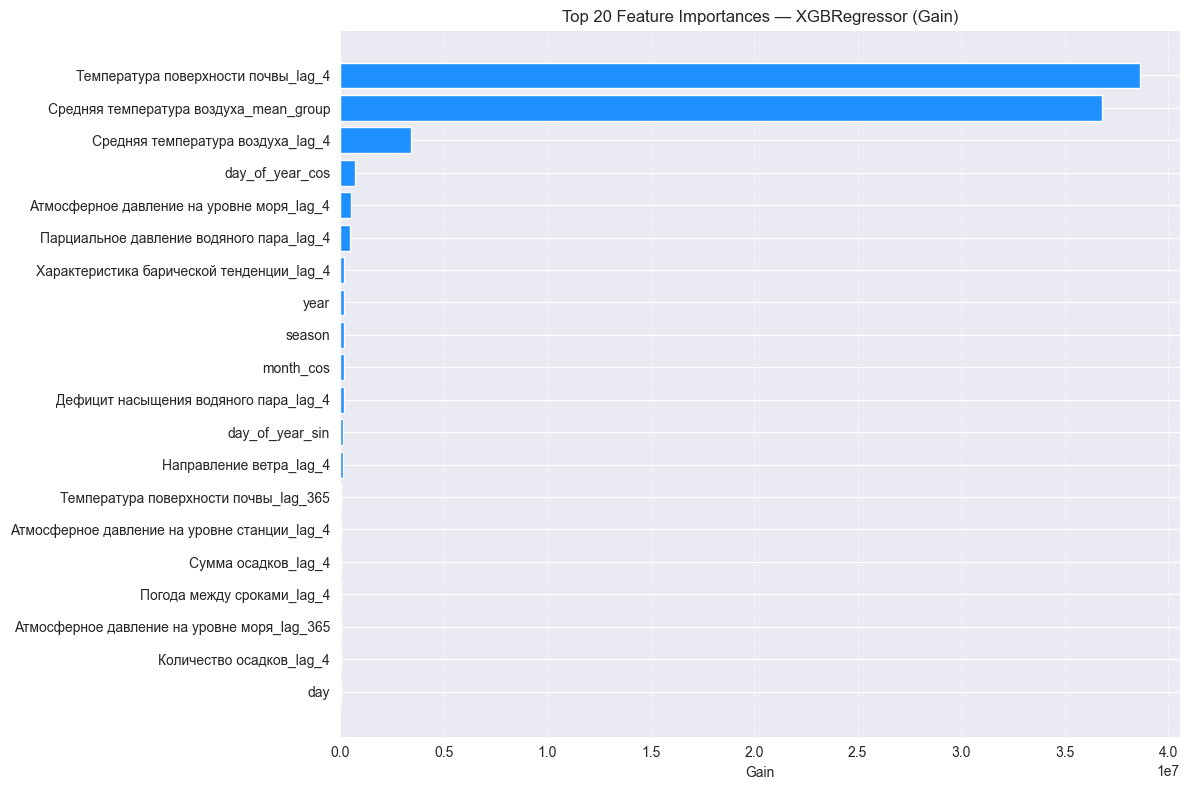

In [432]:
# Получаем важность по gain
gain_importances = model.feature_importance(importance_type='gain')
feature_names = X_train.columns

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': gain_importances
}).sort_values(by='importance', ascending=False)

# Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

plt.figure(figsize=(12, 8))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='dodgerblue')
plt.xlabel('Gain')
plt.title('Top 20 Feature Importances — XGBRegressor (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Сохранение результата и оценка точности

In [433]:
pred_for_fourth = y_pred.copy()

In [434]:
fourth_date = first_date + pd.Timedelta(days=3)

In [435]:
mask = test_df['date'] == fourth_date

y_pred_fourth_day = y_pred[mask]
y_true_fourth_day = y_test[mask]

In [436]:
simple_metric(y_pred_fourth_day, y_true_fourth_day)

Простые метрики:
MAE: 1.3948
MSE: 2.5911
RMSE: 1.6097
MAPE: 6.62%
R²: -5.2101


{'MAE': 1.394802420479911,
 'MSE': 2.591064868793265,
 'RMSE': np.float64(1.6096784985807773),
 'MAPE': np.float64(6.6224882736719985),
 'R2': -5.21014030592154}

### Модель для предсказаний на 5 дней

In [437]:
df_for_five.shape

(109053, 57)

#### Строим лаги

In [438]:
df_for_five = create_lags(df_for_five, original_cols, lag=5)

In [439]:
df_for_five.columns[50:60]

Index(['day_of_year_sin', 'day_of_year_cos', 'season', 'month_sin',
       'month_cos', 'Средняя температура воздуха_mean_group',
       'temp_delta_vs_all_stations', 'Средняя температура воздуха_lag_5',
       'Количество осадков_lag_5', 'Горизонтальная дальность видимости_lag_5'],
      dtype='object')

In [440]:
df_for_five.isna().sum().sum()

np.int64(0)

#### Удаляем оригинальные колонки (Чтобы не было утечек)

In [441]:
target_col

'Средняя температура воздуха'

In [442]:
original_cols[:3]

['Средняя температура воздуха',
 'Количество осадков',
 'Горизонтальная дальность видимости']

In [443]:
cols_to_drop = [
    col for col in original_cols
    if col in df_for_five.columns
       and col != target_col
       and not col.endswith('_missing')
]

df_for_five = df_for_five.drop(columns=cols_to_drop)

In [444]:
df_for_five.shape

(109018, 58)

#### Разделение данных

In [445]:
df_for_five.date.min(), df_for_five.date.max(),

(Timestamp('1982-02-05 00:00:00'), Timestamp('2024-09-25 00:00:00'))

In [446]:
test_start

Timestamp('2024-08-26 00:00:00')

1 месяц на тест

In [447]:
train_df = df_for_five[df_for_five['date'] < test_start].copy()
test_df = df_for_five[df_for_five['date'] >= test_start].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (108801, 58)
Test shape: (217, 58)


In [448]:
train_df = train_df.drop(columns=['date'])
test_df_drop_date = test_df.drop(columns=['date'])

#### Отделяем целевой признак

In [449]:
y_train = train_df['Средняя температура воздуха']
y_test = test_df_drop_date['Средняя температура воздуха']

# Признаки (оставляем Индекс ВМО)
X_train = train_df.drop(columns=['Средняя температура воздуха'])
X_test = test_df_drop_date.drop(columns=['Средняя температура воздуха'])

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (108801, 56) (108801,)
Test shape: (217, 56) (217,)


In [450]:
print(X_train.isna().sum().sum())
print(y_train.isna().sum().sum())
print('Тест:')
print(X_test.isna().sum().sum())
print(y_test.isna().sum().sum())

0
0
Тест:
0
0


#### Построение модели

In [451]:
model = CatBoostRegressor(
    loss_function='RMSE',
    learning_rate=0.1,
    depth=6,
    iterations=500,
    subsample=0.8,
    rsm=0.8,
    random_seed=42,
    verbose=50
)

# Обучение с early stopping
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=20,
    use_best_model=True
)

y_pred = model.predict(X_test)

# Метрика
cat_result = simple_metric(y_test, y_pred)
cat_result

0:	learn: 11.5919189	test: 11.3947904	best: 11.3947904 (0)	total: 15.4ms	remaining: 7.7s
50:	learn: 4.5179004	test: 2.9543636	best: 2.9543636 (50)	total: 1.24s	remaining: 10.9s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 2.910626463
bestIteration = 77

Shrink model to first 78 iterations.
Простые метрики:
MAE: 2.4407
MSE: 8.4717
RMSE: 2.9106
MAPE: 13.72%
R²: 0.3570


{'MAE': 2.440722221820501,
 'MSE': 8.471746359375718,
 'RMSE': np.float64(2.9106264547989866),
 'MAPE': np.float64(13.71842843459444),
 'R2': 0.35701755013574576}

                                      feature  importance
29     Средняя температура воздуха_mean_group   42.041765
48        Температура поверхности почвы_lag_5    9.866579
26                                     season    6.133318
31          Средняя температура воздуха_lag_5    5.974076
25                            day_of_year_cos    4.830128
49   Парциальное давление водяного пара_lag_5    4.225577
28                                  month_cos    3.616432
22                                       year    3.194143
27                                  month_sin    2.810818
24                            day_of_year_sin    2.515502
53  Атмосферное давление на уровне моря_lag_5    2.363591
51      Дефицит насыщения водяного пара_lag_5    2.258074
4       Температура поверхности почвы_lag_335    1.705754
44                    Направление ветра_lag_5    0.994943
54  Характеристика барической тенденции_lag_5    0.766660
3         Средняя температура воздуха_lag_395    0.626588
50      Относи

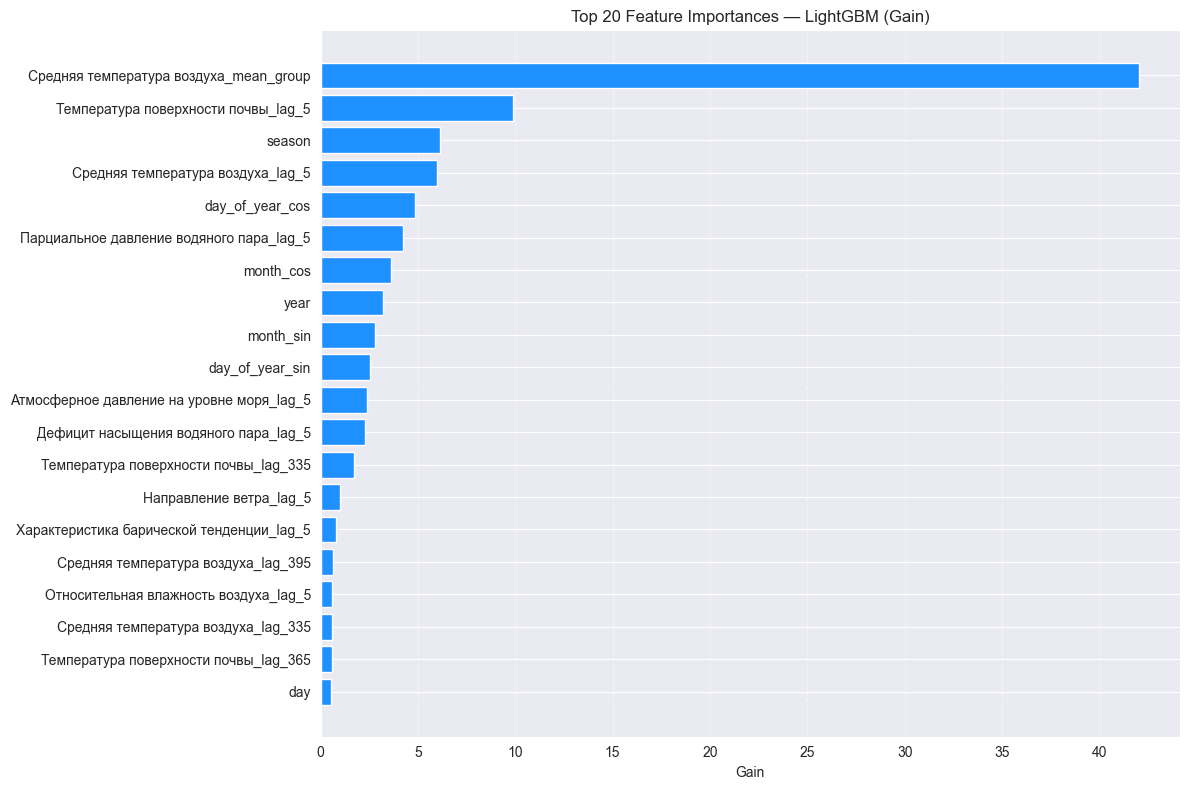

In [452]:
fi = model.get_feature_importance()
feature_names = X_train.columns

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': fi
}).sort_values(by='importance', ascending=False)

# Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

plt.figure(figsize=(12, 8))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='dodgerblue')
plt.xlabel('Gain')
plt.title('Top 20 Feature Importances — LightGBM (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Сохранение результата и оценка точности

In [453]:
pred_for_five = y_pred.copy()

In [454]:
fifth_date = first_date + pd.Timedelta(days=4)

In [455]:
mask = test_df['date'] == fifth_date

y_pred_fifth_day = y_pred[mask]
y_true_fifth_day = y_test[mask]

In [456]:
simple_metric(y_pred_fifth_day, y_true_fifth_day)

Простые метрики:
MAE: 2.5458
MSE: 7.5128
RMSE: 2.7409
MAPE: 12.69%
R²: -26.2036


{'MAE': 2.545844509952827,
 'MSE': 7.51280009388976,
 'RMSE': np.float64(2.7409487579832206),
 'MAPE': np.float64(12.693881672005942),
 'R2': -26.203614593221324}

## Склеивание всех предсказаний

### Истинные значения

In [457]:
y_true = y_test_true
y_true[:5]

array([[22.2, 22.9, 21.6, 22.3, 23.6, 20.7, 21.7, 21.7, 20.1, 16.1, 15.1,
        15.7, 17.7, 20.6, 19.4, 21.3, 22.6, 20. , 20. , 19.5, 18.5, 18.9,
        15.2, 13.6, 15.9, 14.3, 15.7, 11. , 11.4, 11.8],
       [23.5, 24.1, 23.5, 21.7, 24.2, 22.1, 22.2, 22.8, 21.4, 17.2, 16.7,
        17. , 18. , 21.6, 20.5, 21.8, 22.7, 20.5, 20.4, 20.4, 20.6, 19.3,
        16.9, 14.4, 16.3, 13.8, 15.6, 11.6, 13.5, 13.2],
       [21.4, 22. , 22. , 22. , 21.2, 19. , 20.4, 21.2, 18.2, 15. , 15. ,
        15.8, 17.7, 19.4, 19.3, 20.9, 21.8, 19.1, 19. , 18.2, 19. , 17.7,
        14. , 12.8, 16. , 13.5, 15.4, 10.6,  9.7,  9.7],
       [21.9, 21.8, 22.2, 22.4, 21.3, 19.3, 20.7, 21.4, 18.6, 15.2, 14.9,
        16.9, 19. , 20.1, 19.3, 20.9, 22.6, 20.2, 19.6, 18.7, 18.7, 18.6,
        14. , 15. , 18.2, 15.7, 19.4, 11.3, 10.3, 10. ],
       [22.6, 21.9, 23.4, 23.8, 21.3, 19.9, 20.8, 21.8, 19.2, 15.7, 14.6,
        16.3, 20. , 22.2, 21.4, 22.6, 21.8, 19.3, 19.1, 19.3, 19.8, 17.4,
        13.7, 14.9, 15.2, 14.7, 

### Ансамбли

In [458]:
pred_5_days = np.concatenate([
    y_pred_first_day,
    y_pred_second_day,
    y_pred_third_day,
    y_pred_fourth_day,
    y_pred_fifth_day
])

true_5_days = np.concatenate([
    y_true_first_day,
    y_true_second_day,
    y_true_third_day,
    y_true_fourth_day,
    y_true_fifth_day
])

In [459]:
simple_metric(true_5_days, pred_5_days)

Простые метрики:
MAE: 1.4553
MSE: 2.9565
RMSE: 1.7194
MAPE: 6.41%
R²: -3.4324


{'MAE': 1.4552806503405786,
 'MSE': 2.9564787068214,
 'RMSE': np.float64(1.7194413938315547),
 'MAPE': np.float64(6.406015670058261),
 'R2': -3.4323661924565085}

In [460]:
# Простые метрики:
# MAE: 1.4553
# MSE: 2.9565
# RMSE: 1.7194
# MAPE: 6.41%
# R²: -3.4324
# {'MAE': 1.4552806503405786,
#  'MSE': 2.9564787068214,
#  'RMSE': np.float64(1.7194413938315547),
#  'MAPE': np.float64(6.406015670058261),
#  'R2': -3.4323661924565085}

In [461]:
# Простые метрики:
# MAE: 1.8438
# MSE: 5.8709
# RMSE: 2.4230
# MAPE: 11.59%
# R²: -0.1776
# {'MAE': 1.8437614768101063,
#  'MSE': 5.870910963010674,
#  'RMSE': np.float64(2.422996277960549),
#  'MAPE': np.float64(11.59416797459337),
#  'R2': -0.17763145108907996}

In [462]:
pred_5_days = np.concatenate([
    y_pred_first_day,
    y_pred_second_day,
    y_pred_third_day,
    y_pred_fourth_day,
    y_pred_fifth_day
])

In [463]:
pred_list = [
    y_pred_first_day,
    y_pred_second_day,
    y_pred_third_day,
    y_pred_fourth_day,
    y_pred_fifth_day
]
# превращаем в (n_days, n_stations)
pred_5_days = np.vstack(pred_list)

# делаем (n_stations, n_days)
pred_5_days = pred_5_days.T
pred_5_days.shape

(7, 5)

### LSTM

In [464]:
lstm_tail = y_lstm[:, 5:]

In [465]:
lstm_tail.shape

(7, 25)

### Финальное

In [466]:
final_pred = np.hstack([pred_5_days, lstm_tail])
final_pred.shape

(7, 30)

In [467]:
y_true.shape

(7, 30)

In [468]:
df_plot = test_df.copy()
df_plot = df_plot.sort_values(['Индекс ВМО', 'date'])

In [469]:
rows = []
horizon = final_pred.shape[1]

for i, station_id in enumerate(station_ids):
    station_df = df_plot[df_plot['Индекс ВМО'] == station_id].copy()
    station_df = station_df.sort_values('date')

    station_df = station_df.tail(horizon)
    station_df['prediction'] = final_pred[i]

    rows.append(station_df)

df_plot_pred = pd.concat(rows)
df_plot_pred = df_plot_pred.sort_values(['Индекс ВМО', 'date'])

In [470]:
print(len(station_ids))
print(final_pred.shape)
print(df_plot_pred.shape)

7
(7, 30)
(210, 59)


## Итоговая оценка точности

In [471]:
simple_metric(y_true, final_pred)

Простые метрики:
MAE: 2.1253
MSE: 7.2521
RMSE: 2.6930
MAPE: 11.78%
R²: -10.1405


{'MAE': 2.1253119590707517,
 'MSE': 7.252055940333731,
 'RMSE': np.float64(2.6929641550406367),
 'MAPE': np.float64(11.777138365154515),
 'R2': -10.140545392067114}

2 градуса за целый месяц - не так плохо

### Сравнение средних температур

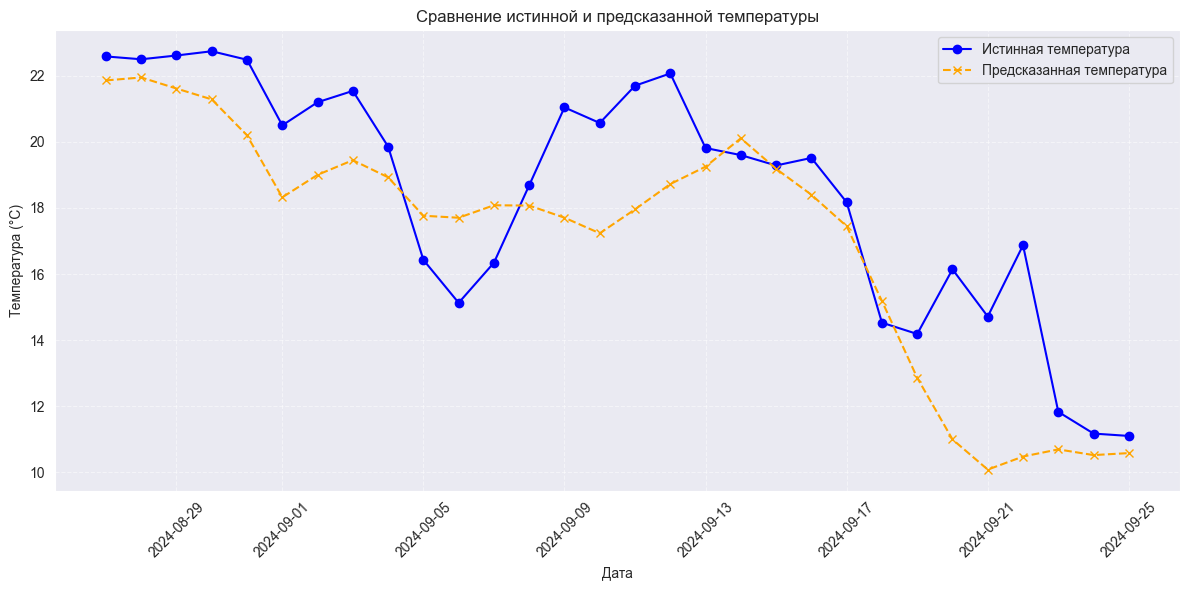

In [472]:
plot_true_vs_pred(df_plot_pred, df_plot_pred['prediction'])

### Сравнение истинной и предсказанной по индексам

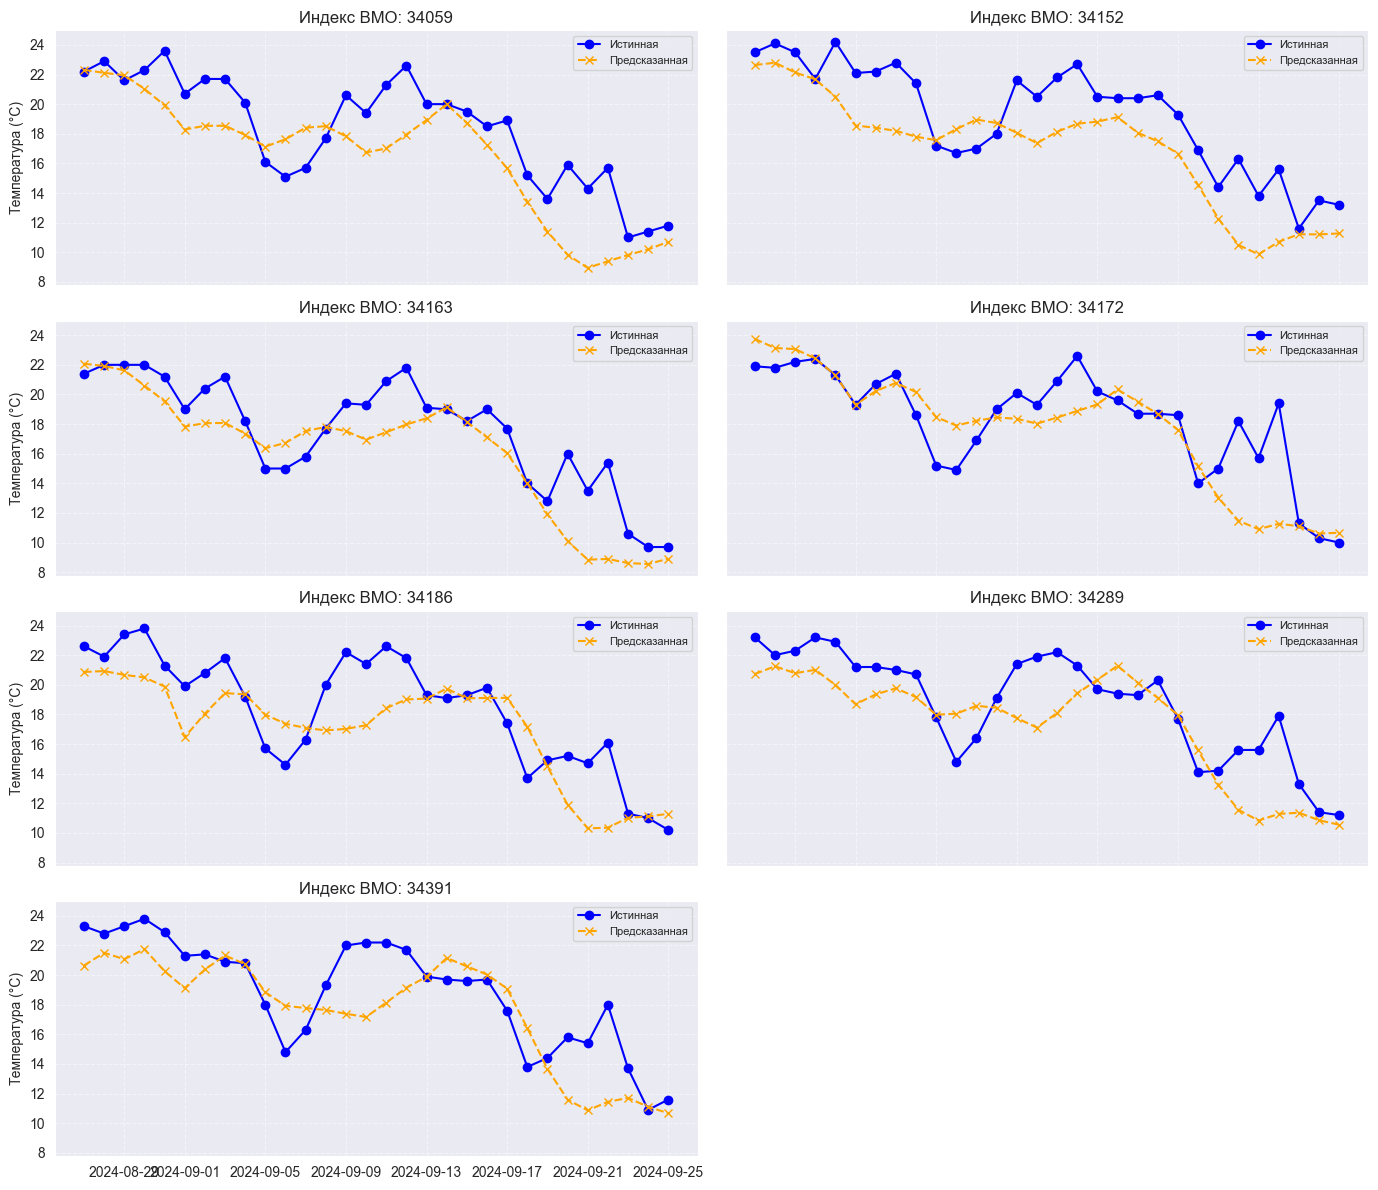

In [473]:
plot_true_vs_pred_by_index(df_plot_pred, df_plot_pred['prediction'])

Хорошо уловил динамику

### Ошибки по индексам

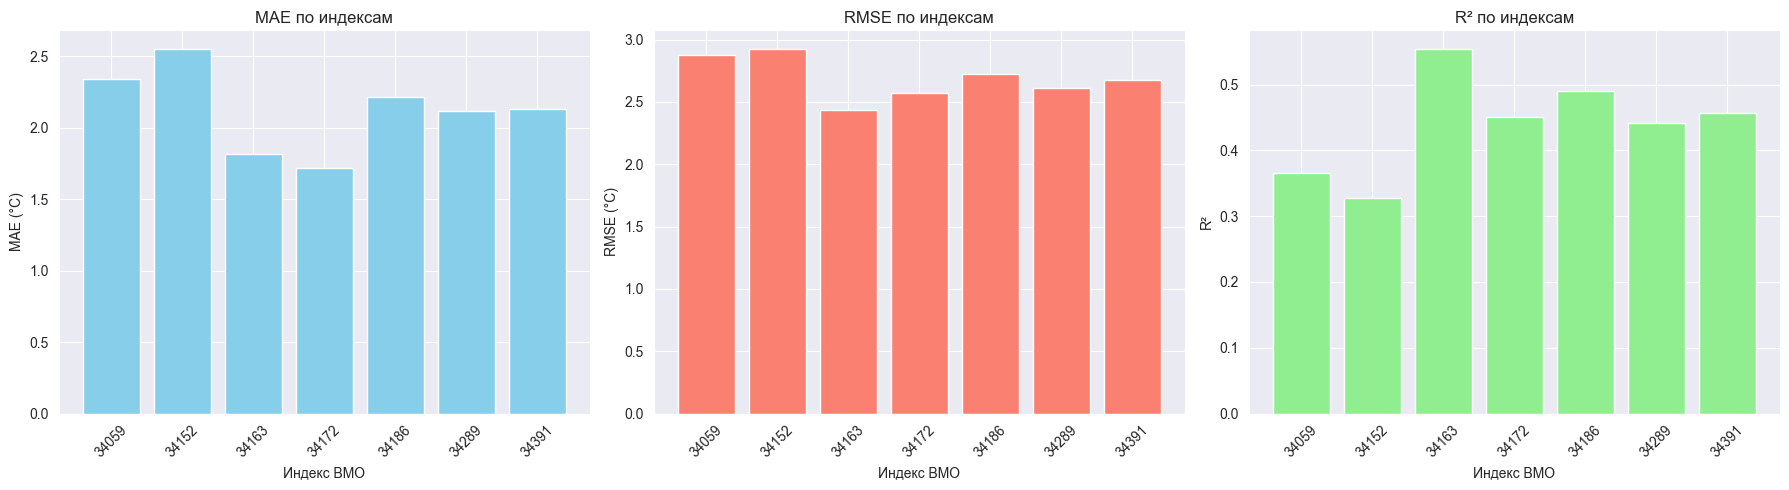

,Индекс ВМО,MAE,RMSE,R2
0,34059,2.336703,2.873997,0.365445
1,34152,2.552748,2.927258,0.327081
2,34163,1.814094,2.438256,0.554749
3,34172,1.715586,2.571005,0.450289
4,34186,2.211300,2.719859,0.489858
5,34289,2.114304,2.612546,0.442238
6,34391,2.132448,2.675351,0.456460


In [474]:
metrics_per_index(df_plot_pred, df_plot_pred['prediction'])

### Накопление ошибки

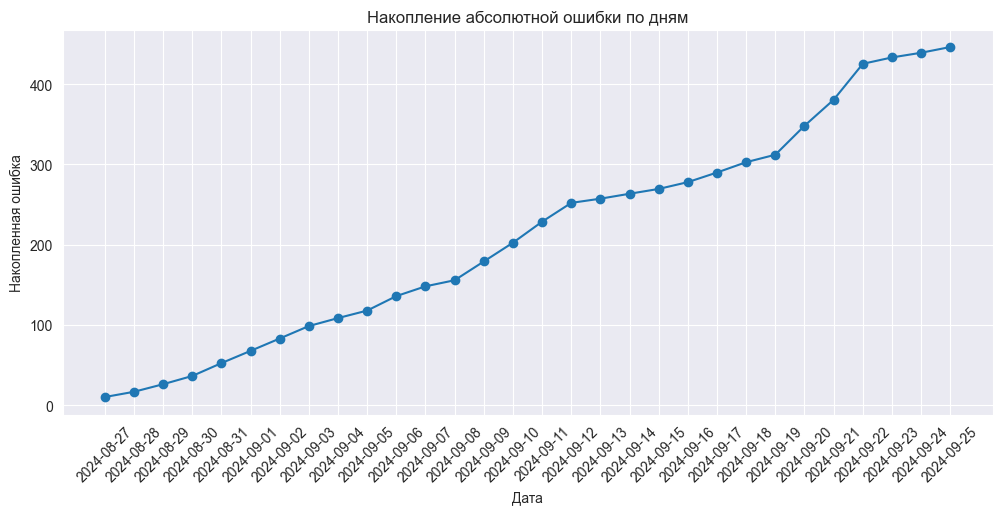

,date,Cumulative_Error
0,2024-08-27,10.360412
1,2024-08-28,16.886974
2,2024-08-29,26.317132
3,2024-08-30,36.580749
4,2024-08-31,52.601661
5,2024-09-01,67.859794
6,2024-09-02,83.240475
7,2024-09-03,98.768406
8,2024-09-04,108.706879
9,2024-09-05,118.056748


In [475]:
cumulative_error(df_plot_pred, df_plot_pred['prediction'])

### Все метрики по дням

In [476]:
daily_metrics(df_plot_pred, df_plot_pred['prediction'])

,date,MAE,RMSE,R2
0,2024-08-27,1.480059,1.723595,-4.547569
1,2024-08-28,0.932366,1.020994,-0.754087
2,2024-08-29,1.347166,1.585873,-3.961141
3,2024-08-30,1.466231,1.830607,-4.334792
4,2024-08-31,2.288702,2.602700,-4.275401
5,2024-09-01,2.179733,2.467369,-4.477556
6,2024-09-02,2.197240,2.451974,-16.985141
7,2024-09-03,2.218276,2.634980,-18.308328
8,2024-09-04,1.419782,1.822538,-1.643074
9,2024-09-05,1.335696,1.680174,-1.163376
